In [1]:
import os
os.chdir(os.pardir)

from src.utils import AIDatasetLoader, filter_by_app_and_model, DecisionTreeInterpreter, LogisticRegressionInterpreter  
from src.memory import Chunk, DeclarativeMemory

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## 1. Load datasets

In [2]:
current_dir = os.getcwd()
data_dir = os.path.join(current_dir, 'datasets')

file_values = os.path.join(data_dir, 'values.csv')
file_metadata = os.path.join(data_dir, 'metadata.csv')
file_prediction = os.path.join(data_dir, 'none.csv')

values_df = pd.read_csv(file_values)
metadata_df = pd.read_csv(file_metadata)
prediction_df = pd.read_csv(file_prediction)

# ✅ Which model to use per dataset
dataset_model_map = {
    "mushrooms": "mlp",
    "wine_quality": "mlp",
    "forest_cover": "xgboost",
    "adult": "xgboost",
}

# # 🔧 Choose dataset here:
# app_id = "wine_quality"  # 🔄 Change this line to switch datasets

# # 🧠 Auto-configured values:
# model_name = dataset_model_map[app_id]

# load ai loader
ai_dataset_loader = AIDatasetLoader(
    feature_values_df=values_df,
    metadata_df=metadata_df,
    AI_predictions_df=prediction_df
)

# Load decision tree
dt_df = pd.read_csv(os.path.join(data_dir, 'decision_tree.csv'))
# dt_exp = DecisionTreeInterpreter(dt_df, metadata_df, app_id, model_name, depth=2)
# dt_exp.print_tree(as_name=True)


# Load linear model
lr_df = pd.read_csv(os.path.join(data_dir, 'logistic_regression.csv'))
# lr_exp = LogisticRegressionInterpreter(lr_df, metadata_df, app_id, model_name, variant="sparse")

In [3]:
# ✅ Which model to use per dataset
dataset_model_map = {
    "mushrooms": "mlp",
    "wine_quality": "mlp",
    "forest_cover": "mlp",
    "adult": "mlp",
}

# 🔧 Choose dataset here:
# 📋 Dataset mapping dictionary
dataset_mapping = {
    1: "wine_quality",
    2: "mushrooms", 
    3: "forest_cover",
    4: "adult"
}

app_id1 = dataset_mapping[1]  # wine_quality
app_id2 = dataset_mapping[2]  # mushrooms
app_id3 = dataset_mapping[3]  # forest_cover
app_id4 = dataset_mapping[4]  # adult

# 🧠 Auto-configured values:
model_name1 = dataset_model_map[app_id1]
model_name2 = dataset_model_map[app_id2]
model_name3 = dataset_model_map[app_id3]
model_name4 = dataset_model_map[app_id4]

# load ai loader
ai_dataset_loader = AIDatasetLoader(
    feature_values_df=values_df,
    metadata_df=metadata_df,
    AI_predictions_df=prediction_df
)

ai_data_loader1 = filter_by_app_and_model(ai_dataset_loader, app_id1, model_name1)
ai_data_loader2 = filter_by_app_and_model(ai_dataset_loader, app_id2, model_name2)
ai_data_loader3 = filter_by_app_and_model(ai_dataset_loader, app_id3, model_name3)
ai_data_loader4 = filter_by_app_and_model(ai_dataset_loader, app_id4, model_name4)

# instances, preds = ai_dataset_loader.load_instances(list(range(20)), normalize=False)  # Load instances

# Load decision tree
dt_df = pd.read_csv(os.path.join(data_dir, 'decision_tree.csv'))
dt_exp1 = DecisionTreeInterpreter(dt_df, metadata_df, app_id1, model_name1)
dt_exp1.print_tree(as_name=True)
dt_exp2 = DecisionTreeInterpreter(dt_df, metadata_df, app_id2, model_name2)
dt_exp2.print_tree(as_name=True)
dt_exp3 = DecisionTreeInterpreter(dt_df, metadata_df, app_id3, model_name3)
dt_exp3.print_tree(as_name=True)
dt_exp4 = DecisionTreeInterpreter(dt_df, metadata_df, app_id4, model_name4)
dt_exp4.print_tree(as_name=True)


# Load linear model
lr_df = pd.read_csv(os.path.join(data_dir, 'logistic_regression.csv'))
lr_exp1 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id1, model_name1)
lr_exp2 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id2, model_name2)
lr_exp3 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id3, model_name3)
lr_exp4 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id4, model_name4)
lr_exp5 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id1, model_name1, variant="sparse")
lr_exp6 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id2, model_name2, variant="sparse")
lr_exp7 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id3, model_name3, variant="sparse")
lr_exp8 = LogisticRegressionInterpreter(lr_df, metadata_df, app_id4, model_name4, variant="sparse")

ai_dataset_loaders = {
    1: ai_data_loader1,
    2: ai_data_loader2,
    3: ai_data_loader3,
    4: ai_data_loader4,
    5: ai_data_loader1,
    6: ai_data_loader2,
    7: ai_data_loader3,
    8: ai_data_loader4
}

lr_exps = {
    1: lr_exp1,     
    2: lr_exp2,
    3: lr_exp3,
    4: lr_exp4,
    5: lr_exp5,     
    6: lr_exp6,
    7: lr_exp7,
    8: lr_exp8
}


Decision Tree (appId=wine_quality, model=mlp)
Fidelity: 0.9550
if Alcohol <= 10.849999904632568:
  if Vinegar Taint <= 0.375:
    if Sulphates <= 0.6049999892711639:
      → Predict 0 (probs: [0.8 0.2])
    else:
      → Predict 1 (probs: [0. 1.])
  else:
    if Sulphates <= 1.64000004529953:
      → Predict 0 (probs: [0.9818 0.0182])
    else:
      → Predict 1 (probs: [0. 1.])
else:
  if Vinegar Taint <= 0.5649999976158142:
    if Sulphates <= 0.5049999952316284:
      → Predict 0 (probs: [0.5 0.5])
    else:
      → Predict 1 (probs: [0. 1.])
  else:
    if Alcohol <= 12.400000095367432:
      → Predict 0 (probs: [0.8889 0.1111])
    else:
      → Predict 1 (probs: [0. 1.])
Decision Tree (appId=mushrooms, model=mlp)
Fidelity: 0.8000
if Height <= 3.4250000715255737:
  if Cap Diameter <= 3.284999966621399:
    if Shape = flat <= 0.5:
      → Predict 0 (probs: [1. 0.])
    else:
      → Predict 0 (probs: [0.6538 0.3462])
  else:
    if Width <= 3.944999933242798:
      → Predict 0 (pro

In [4]:

import importlib
import src.memory as memory
importlib.reload(memory)
import src.dt_memory as dt_memory
importlib.reload(dt_memory)
import src.heuristic_lr_model as heuristic_lr_model
importlib.reload(heuristic_lr_model)
import src.lr_memory as lr_memory
importlib.reload(lr_memory)

from src.memory import DeclarativeMemory, CombinedMemory
from src.dt_memory import (
    add_dt_to_memory, dt_traverse, refresh_dt_path_in_memory
)
from src.heuristic_lr_model import (
    add_lr_heuristic_to_memory, lr_heuristic, refresh_lr_heuristic_in_memory
)
from src.lr_memory import (
    add_lr_calculation_to_memory, lr_calculation, refresh_lr_calculation_in_memory
)

from typing import Optional
import random
from dataclasses import replace

In [5]:
# ---------------- Memory builder ----------------
def _make_memory(retrieval_threshold, latency_factor):
    dm = DeclarativeMemory(
        retrieval_threshold=retrieval_threshold,
        latency_factor=latency_factor,
        latency_exponent=0.5,
        max_assoc_strength=2.0,
        mismatch_penalty=-2.0,
        activation_noise=0.3,
        decay=0.5,
    )
    return CombinedMemory(dm, wm_capacity=7)

# def _select_prob(probs, y):
#     if hasattr(probs, "__len__") and len(probs) == 2:
#         return float(probs[1]) if float(y) > 0 else float(probs[0])
#     raise ValueError(f"Unexpected probs format: {probs}")


# ---------------- Strategy adapters ----------------
# def _seed_memory_for_strategy(strategy, memory, explainer, compute_sf):
#     """
#     Initializes memory for the chosen strategy.
#     """
#     if strategy == "lr_calc":
#         # preload LR coefficients for calculation path
#         add_lr_calculation_to_memory(explainer, memory)
#     elif strategy == "lr_heur":
#         # preload LR heuristic state (use your preferred init var)
#         add_lr_heuristic_to_memory(explainer, memory, initial_var=1.0)
#     elif strategy == "dt":
#         # preload DT structure (threshold sig figs follow compute_sf)
#         add_dt_to_memory(memory, explainer, thresh_sf=int(compute_sf))
#     else:
#         raise ValueError(f"Unknown strategy: {strategy!r}")


def _predict_once(strategy, instance, norm_instance, memory, explainer, *, with_xai,
                  T_enc, T_op, ddm_a, ddm_s, compute_sf):
    """
    Runs ONE trial under the chosen strategy and returns:
      probs, pred_time, aux_info
    """
    if strategy == "lr_calc":
        # lr_calculation in 'read' or 'retrieve'
        probs, pred_time, aux = lr_calculation(
            instance, memory, lr_exp=explainer,
            T_enc=T_enc, T_op=T_op, ddm_a=ddm_a, ddm_s=ddm_s,
            compute_sf=compute_sf,
            mode=("read" if with_xai else "retrieve"),
        )
        return probs, pred_time, aux

    elif strategy == "lr_heur":
        # heuristic maps T_enc->T_READ_NUM, T_op->T_INTUITIVE_OP
        probs, pred_time, info = lr_heuristic(
            norm_instance, memory, explainer,
            num_samples=40, K_top=3,
            T_READ_NUM=T_enc, T_INTUITIVE_OP=T_op,
            ddm_a=ddm_a, ddm_s=ddm_s, ddm_Tnd=0.30, ddm_norm="l2",
            active_indices=None, verbose=False
        )
        return probs, pred_time, info

    elif strategy == "dt":
        # dt_traverse in 'read' or 'retrieve'
        probs, pred_time, aux = dt_traverse(
            instance, memory, explainer,
            mode=("read" if with_xai else "retrieve"),
            compute_sf=int(compute_sf),
            T_enc=T_enc, ddm_a=ddm_a, ddm_s=ddm_s, ddm_Tnd=0.30, ddm_norm="l2",
            n_mc=64, topk_k=3, refresh_prob_cap=1.0, verbose=False
        )
        return probs, pred_time, aux

    else:
        raise ValueError(f"Unknown strategy: {strategy!r}")


def _post_read_refresh(strategy, memory, explainer, *, compute_sf, info_or_aux, instance, with_xai, actual_label, active_indices=None):
    """
    Applies post-read/online refresh depending on strategy.
    - For lr_calc: refresh only when with_xai=True (as before).
    - For lr_heur: refresh on BOTH. If with_xai=False, use model’s own pred as 'actual'.
    - For dt:      after read, refresh the path; retrieve-mode may use refresh_prob_cap internally.
    """
    if strategy == "lr_calc":
        if with_xai:
            refresh_lr_calculation_in_memory(
                memory, explainer,
                intercept_display_sf=int(compute_sf),
                factor_display_sf=int(compute_sf),
                #active_indices=active_indices
            )

    elif strategy == "lr_heur":
        # 'info_or_aux' is the 'info' dict returned by lr_heuristic
        info = info_or_aux
        # actual_label already set by caller to either human response (with XAI) or model pred (w/o XAI)
        refresh_lr_heuristic_in_memory(
            memory, explainer, info, actual=int(actual_label),
            active_indices=active_indices, w_min=1e-4, verbose=False
        )

    elif strategy == "dt":
        if with_xai:
            # refresh the path after reading explanations
            # (thresh_sf ties to compute_sf for consistency)
            refresh_dt_path_in_memory(memory, explainer, instance, thresh_sf=int(compute_sf))

In [6]:
# import numpy as np
# import gymnasium as gym
# from gymnasium import spaces

# # ===================== Action → Mode mapping (outside the class) =====================
# # 1: "with XAI"  -> lr_calculation(..., mode="read")
# # 2: "without XAI" -> lr_calculation(..., mode="retrieve")
# LR_ACTIONS = {
#     1: "read",
#     2: "retrieve",
# }


# class LRForward(gym.Env):
#     """
#     LR-only environment with 2 strategy actions (with/without XAI) + feature mask.

#     Actions (Box, float32, shape=(2 + max_features,), all entries ∈ [0,1]):
#       a[0]: strategy selector (normalized) -> {0,1,2} via floor(a[0]*3)
#             0 = invalid (penalty), 1 = "read", 2 = "retrieve"
#       a[1]: ddm_a normalized selector ∈ [0,1] mapped to [ddm_a_min, ddm_a_max]
#       a[2:2+max_features]: feature mask; values >= 0.5 treated as 1, else 0

#     Trial schedule:
#       - Each episode creates a with-XAI schedule by xai_trial_ratio.
#       - On with-XAI trials, both strategies allowed.
#       - On without-XAI trials, only "retrieve" allowed; choosing "read" yields a penalty.

#     Observation (float32):
#       [chi_norm, trial_idx_norm, with_xai_flag,
#        strategy_counts[2], strategy_success_rates[2],
#        per-feature contribution-std distribution [max_features],
#        per-feature mean distribution [max_features],
#        (optional) varied cognitive params except 'chi' and 'ddm_a']

#     Reward:
#       prob_correct - chi * pred_time
#     """

#     metadata = {"render_modes": ["human"]}

#     def __init__(
#         self,
#         *,
#         instances_per_episode: int = 40,
#         max_features: int = 6,
#         xai_trial_ratio: float = 0.5,
#         ai_dataset_loaders=None,
#         lr_exps=None,
#         training: bool = True,
#         cog_params: dict = None,       # expect {"chi": (lo, hi), "ddm_a": (lo, hi), ...}
#         complexity: str = "low",
#     ):
#         super().__init__()

#         self.shuffle_features = True
#         self.perm = None
#         self.inv_perm = None

#         self.instances_per_episode = int(instances_per_episode)
#         self.max_features = int(max_features)
#         self.xai_trial_ratio = float(xai_trial_ratio)

#         # --- ddm_a range from cog_params (fallback to [1.0, 1.0]) ---
#         self.ddm_a_min, self.ddm_a_max = 1.0, 1.0
#         if cog_params and isinstance(cog_params.get("ddm_a", None), (list, tuple)) and len(cog_params["ddm_a"]) == 2:
#             self.ddm_a_min = float(cog_params["ddm_a"][0])
#             self.ddm_a_max = float(cog_params["ddm_a"][1])

#         # --- chi range moved into cog_params (fallback to [0.0, 0.03]) ---
#         chi_low, chi_high = 0.0, 0.03
#         if cog_params and isinstance(cog_params.get("chi", None), (list, tuple)) and len(cog_params["chi"]) == 2:
#             chi_low, chi_high = float(cog_params["chi"][0]), float(cog_params["chi"][1])
#         self.chi_low = chi_low
#         self.chi_high = chi_high

#         self.ai_dataset_loaders = ai_dataset_loaders or {}
#         self.lr_exps = lr_exps or {}

#         # -------- Action space (SINGLE Box) --------
#         # [ strategy_norm, ddm_a_norm, mask_0, ..., mask_{max_features-1} ]  all in [0,1]
#         self.action_space = spaces.Box(
#             low=0.0,
#             high=1.0,
#             shape=(2 + self.max_features,),
#             dtype=np.float32,
#         )

#         # -------- Cognitive params (episode-varying) --------
#         self.cog_params = cog_params or {}
#         self.num_varied_cogparam = 0
#         self.varied_cogparams_low = []
#         self.varied_cogparams_high = []
#         for k, v in self.cog_params.items():
#             if k in ["chi", "ddm_a"]:
#                 continue  # handled above or action-controlled
#             if isinstance(v, (list, tuple)) and len(v) == 2:
#                 self.num_varied_cogparam += 1
#                 self.varied_cogparams_low.append(float(v[0]))
#                 self.varied_cogparams_high.append(float(v[1]))

#         # -------- Observation space --------
#         low_vec = [0.0, 0.0, 0.0]                        # chi_norm, trial_norm, with_xai_flag
#         high_vec = [1.0, 1.0, 1.0]

#         low_vec += [0.0] * 2                             # strategy_counts (lo)
#         high_vec += [float(self.instances_per_episode)] * 2

#         low_vec += [0.0] * 2                             # strategy_success rates (lo)
#         high_vec += [1.0] * 2

#         low_vec += [0.0] * self.max_features             # per-feature std distribution (lo)
#         high_vec += [1.0] * self.max_features            # per-feature std distribution (hi)

#         low_vec += [0.0] * self.max_features             # per-feature mean distribution (lo)
#         high_vec += [1.0] * self.max_features            # per-feature mean distribution (hi)

#         if self.num_varied_cogparam > 0:
#             low_vec += self.varied_cogparams_low
#             high_vec += self.varied_cogparams_high

#         self.observation_space = spaces.Box(
#             low=np.array(low_vec, dtype=np.float32),
#             high=np.array(high_vec, dtype=np.float32),
#             dtype=np.float32,
#         )

#         # temperature for sigmoids (tune 3.0–10.0)
#         self.gate_beta = 5.0

#         # Episode state
#         self.step_idx = 0
#         self.curr_chi = 0.0
#         self.training = bool(training)
#         self.complexity = complexity

#         self.memory = None
#         self.lr_exp = None
#         self.ai_dataset_loader = None

#         self.strategy_counts = np.zeros(2, dtype=np.int32)   # [count_read, count_retrieve]
#         self.strategy_success = np.zeros(2, dtype=np.float32)

#         self.contributions = {i: [] for i in range(self.max_features)}
#         self.current_cog_params = {}
#         self.with_xai_schedule = None

#     # ---------------------- internal helpers ----------------------
#     def _sigmoid01(self, x, beta=5.0):
#             # map [0,1] -> [0,1] with slope around 0.5
#             z = np.clip(x, 1e-6, 1.0-1e-6)
#             s = 1.0 / (1.0 + np.exp(-beta * (z - 0.5)))
#             return np.clip(s, 1e-6, 1.0-1e-6)


#     def _initialize_memory(self):
#         """
#         Build memory using _make_memory with only retrieval_threshold and latency_factor
#         possibly varying episode-by-episode.
#         """
#         rt = float(self.current_cog_params.get("retrieval_threshold", 0.5))
#         lf = float(self.current_cog_params.get("latency_factor", 3.0))
#         self.memory = _make_memory(rt, lf)

#         # Seed LR calculation knowledge in memory
#         if self.lr_exp is not None:
#             add_lr_calculation_to_memory(self.lr_exp, self.memory)

#         # Warm-up time
#         self.memory.tick(90)

#     def _get_strategy_params(self):
#         """
#         Collect lr_calculation knobs (timing/diffusion/precision), allowing
#         episode-varying overrides from self.current_cog_params.
#         Note: ddm_a will be supplied per-action in step().
#         """
#         params = dict(
#             T_enc=2.0,
#             T_op=0.2,
#             ddm_a=1.0,            # placeholder; overridden in step() from action
#             ddm_s=1.0,
#             ddm_Tnd=0.30,
#             ddm_norm="l2",
#             compute_sf=2,
#             lapse=0.05,
#         )
#         for k, v in (self.current_cog_params or {}).items():
#             if k in params and isinstance(v, (int, float)) and k != "ddm_a":
#                 params[k] = float(v)
#         return params

#     def _build_with_xai_schedule(self, n, ratio, rng):
#         """
#         Return np.array of length n with booleans for with-XAI trials.
#         """
#         n_xai = int(round(n * ratio))
#         flags = np.array([1] * n_xai + [0] * (n - n_xai), dtype=np.int32)
#         rng.shuffle(flags)
#         return flags.astype(bool)

#     def _build_obs(self):
#         # If episode ended, return a valid zero-like observation
#         if self.step_idx >= self.instances_per_episode:
#             return np.zeros(self.observation_space.shape, dtype=np.float32)

#         with_xai_flag = float(self.with_xai_schedule[self.step_idx])

#         # Feature contribution tracking
#         x_raw = self.X_raw[self.step_idx]
#         for feat in range(min(self.max_features, x_raw.shape[-1])):
#             if self.lr_exp is not None and hasattr(self.lr_exp, "coefficients"):
#                 factor_value = self.lr_exp.coefficients.get(f"a{feat}", 0.0)
#             else:
#                 factor_value = 0.0
#             self.contributions[feat].append(float(x_raw[feat]) * float(factor_value))

#         # per-feature std distribution
#         feature_stds = np.array([
#             np.std(self.contributions[i]) if len(self.contributions[i]) > 1 else 0.0
#             for i in range(self.max_features)
#         ], dtype=np.float32)
#         if feature_stds.sum() > 0:
#             partial_sums_std = (feature_stds / feature_stds.sum()).astype(np.float32)
#         else:
#             partial_sums_std = feature_stds

#         # per-feature mean distribution (normalized)
#         feature_means = np.array([
#             np.mean(self.contributions[i]) if len(self.contributions[i]) > 0 else 0.0
#             for i in range(self.max_features)
#         ], dtype=np.float32)
#         if abs(feature_means).sum() != 0:
#             partial_sums_mean = (abs(feature_means) / (abs(feature_means).sum() + 1e-9)).astype(np.float32)
#         else:
#             partial_sums_mean = feature_means

#         if self.perm is not None:
#             partial_sums_std = partial_sums_std[self.perm]
#             partial_sums_mean = partial_sums_mean[self.perm]

#         base = [
#             float(self.curr_chi / max(self.chi_high, 1e-9)),
#             float(self.step_idx / max(self.instances_per_episode, 1)),
#             with_xai_flag,
#             *self.strategy_counts.tolist(),
#             *self.strategy_success.tolist(),
#             *partial_sums_std.tolist(),
#             *partial_sums_mean.tolist(),
#         ]

#         if self.num_varied_cogparam > 0:
#             cog_obs = [
#                 float(self.current_cog_params.get(k, 0.0))
#                 for k, v in self.cog_params.items()
#                 if isinstance(v, (list, tuple)) and len(v) == 2 and (k not in ["chi", "ddm_a"])
#             ]
#             base += cog_obs

#         return np.asarray(base, dtype=np.float32)

#     # --------------------------- Gym API ---------------------------

#     def reset(self, seed=None, options=None):
#         super().reset(seed=seed)
#         rng = np.random.default_rng(seed)

#         # Per-episode feature permutation
#         if self.shuffle_features:
#             self.perm = rng.permutation(self.max_features).astype(np.int64)
#             inv = np.empty_like(self.perm)
#             inv[self.perm] = np.arange(self.max_features, dtype=np.int64)
#             self.inv_perm = inv
#         else:
#             self.perm = np.arange(self.max_features, dtype=np.int64)
#             self.inv_perm = np.arange(self.max_features, dtype=np.int64)

#         # Randomly select dataset key and bind loader/exp
#         if not self.ai_dataset_loaders:
#             raise RuntimeError("ai_dataset_loaders is empty.")
#         dataset_key = rng.choice(list(self.ai_dataset_loaders.keys()))
#         self.ai_dataset_loader = self.ai_dataset_loaders[dataset_key]
#         self.lr_exp = (self.lr_exps or {}).get(dataset_key, None)

#         # Episode-varying cognitive params
#         self.current_cog_params = {}
#         for k, v in (self.cog_params or {}).items():
#             if isinstance(v, (list, tuple)) and len(v) == 2:
#                 self.current_cog_params[k] = float(rng.uniform(v[0], v[1]))
#             elif isinstance(v, (int, float)):
#                 self.current_cog_params[k] = float(v)

#         # Build memory via _make_memory
#         self._initialize_memory()

#         # With-XAI schedule for the whole episode
#         self.with_xai_schedule = self._build_with_xai_schedule(
#             self.instances_per_episode, self.xai_trial_ratio, rng
#         )

#         self.step_idx = 0
#         self.curr_chi = float(rng.uniform(self.chi_low, self.chi_high))

#         # Reset trackers
#         self.strategy_counts[:] = 0
#         self.strategy_success[:] = 0.0
#         self.contributions = {i: [] for i in range(self.max_features)}

#         # Sample instances for the episode (adapt to your dataset size)
#         all_idx = list(range(1, 400))
#         idx = rng.choice(all_idx, size=self.instances_per_episode, replace=False).tolist()
#         inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
#         inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)
#         self.X_raw = np.asarray(inst_raw, dtype=np.float32)
#         self.X_norm = np.asarray(inst_norm, dtype=np.float32)
#         self.y = np.asarray(labels, dtype=np.int64)

#         return self._build_obs(), {}

#     def step(self, action):
#         # ---- in step(self, action) replace the decode block ----
#         a = np.asarray(action, dtype=np.float32).reshape(-1)
#         if a.shape[0] != (2 + self.max_features):
#             return self._build_obs(), -5.0, False, False, {"error": "Bad action shape"}

#         # 1) continuous ddm_a (actually used)
#         ddm_a_norm = float(np.clip(a[0], 0.0, 1.0))
#         ddm_a = self.ddm_a_min + ddm_a_norm * (self.ddm_a_max - self.ddm_a_min)
#         ddm_a = 1.0

#         # 2) strategy as probabilistic gate (read vs retrieve)
#         with_xai_trial = bool(self.with_xai_schedule[self.step_idx])
#         p_read = self._sigmoid01(float(a[1]), beta=self.gate_beta)
#         chosen_mode = "read" if (np.random.rand() < p_read) else "retrieve"

#         # Illegal action handling: penalize if chosen_mode is "read" on a no-XAI trial
#         if (not with_xai_trial) and (chosen_mode == "read"):
#             self.step_idx += 1
#             truncated = self.step_idx >= self.instances_per_episode
#             info = {
#                 "illegal_action": True,
#                 "chosen_mode": chosen_mode,
#                 "with_xai_trial": with_xai_trial,
#                 "p_read": float(p_read),
#             }
#             return self._build_obs(), -3.0, False, truncated, info

#         # 3) mask as Bernoulli from sigmoids
#         mask_logits = a[2:2 + self.max_features]
#         p_mask = self._sigmoid01(mask_logits, beta=self.gate_beta)
#         mask_bits = (np.random.rand(self.max_features) < p_mask).astype(np.int64)

#         # ensure at least one feature
#         if mask_bits.sum() == 0:
#             j = int(np.argmax(p_mask))
#             mask_bits[j] = 1

#         # map shuffled positions -> original feature indices
#         active_shuf = [i for i, b in enumerate(mask_bits) if b == 1]
#         active_indices = [int(self.perm[i]) for i in active_shuf]

#         # # Invalid action id (0 or >2) → penalty
#         # if action_id not in LR_ACTIONS:
#         #     self.step_idx += 1
#         #     truncated = self.step_idx >= self.instances_per_episode
#         #     info = {"error": f"Invalid action id {action_id}", "chi": self.curr_chi}
#         #     return self._build_obs(), -5.0, False, truncated, info

#         # # Trial mode constraints
#         # with_xai_trial = bool(self.with_xai_schedule[self.step_idx])
#         # chosen_mode = LR_ACTIONS[action_id]  # "read" or "retrieve"

#         # If the trial is without-XAI, only "retrieve" is allowed
#         # if (not with_xai_trial) and (chosen_mode == "read"):
#         #     self.step_idx += 1
#         #     truncated = self.step_idx >= self.instances_per_episode
#         #     info = {
#         #         "invalid_on_no_xai_trial": True,
#         #         "chosen_mode": chosen_mode,
#         #         "with_xai_trial": with_xai_trial,
#         #     }
#         #     return self._build_obs(), -3.0, False, truncated, info

#         # Fetch current instance
#         x_raw = self.X_raw[self.step_idx]
#         y_true = int(self.y[self.step_idx])

#         # Params for lr_calculation
#         SP = self._get_strategy_params()
#         SP["ddm_a"] = float(ddm_a)  # override ddm_a from action

#         # Run lr_calculation in the chosen mode
#         probs, pred_time, _ = lr_calculation(
#             x_raw, self.memory, lr_exp=self.lr_exp,
#             T_enc=SP["T_enc"], T_op=SP["T_op"],
#             ddm_a=SP["ddm_a"], ddm_s=SP["ddm_s"],
#             compute_sf=int(SP["compute_sf"]),
#             mode=chosen_mode, active_indices=active_indices
#         )

#         if chosen_mode == "read":
#             # Post-read refresh
#             _post_read_refresh(
#                 "lr_calc", self.memory, self.lr_exp,
#                 compute_sf=SP["compute_sf"],
#                 info_or_aux=None,
#                 instance=x_raw,
#                 with_xai=with_xai_trial,
#                 actual_label=None,
#             )

#         # Reward
#         prob_correct = float(probs[y_true])
#         if SP["lapse"] > 0.0:
#             prob_correct = (1.0 - SP["lapse"]) * prob_correct + 0.5 * SP["lapse"]
#         reward = prob_correct - float(self.curr_chi) * float(pred_time)

#         # Update per-strategy stats (index 0: read, 1: retrieve)
#         idx = 0 if (chosen_mode == "read") else 1
#         self.strategy_counts[idx] += 1
#         n = self.strategy_counts[idx]
#         old_mean = self.strategy_success[idx]
#         self.strategy_success[idx] = (old_mean * (n - 1) + (1.0 if prob_correct > 0.5 else 0.0)) / max(n, 1)

#         # Advance
#         self.step_idx += 1
#         truncated = self.step_idx >= self.instances_per_episode

#         obs = self._build_obs()
#         info = {
#             # "action_id": action_id,
#             "chosen_mode": chosen_mode,
#             "with_xai_trial": with_xai_trial,
#             "prob_correct": prob_correct,
#             "pred_time": float(pred_time),
#             "ddm_a": float(ddm_a),
#             "active_indices_orig": active_indices,
#             "active_indices_shuf": active_shuf,
#             "chi": self.curr_chi,
#             "cog_params": dict(self.current_cog_params),
#         }
#         return obs, float(reward), False, truncated, info


In [7]:
import numpy as np
import gymnasium as gym
from gymnasium import spaces

# 1: "with XAI"  -> lr_calculation(..., mode="read")
# 2: "without XAI" -> lr_calculation(..., mode="retrieve")
LR_ACTIONS = {1: "read", 2: "retrieve"}

class LRForward(gym.Env):
    """
    Discrete env + quantized ddm_a.

    Action (MultiDiscrete):
      a[0] ∈ {0,1,2}    -> 0 invalid (penalty), 1="read", 2="retrieve"
      a[1] ∈ {0..B-1}   -> ddm_a bin (B = ddm_a_bins)
      a[2:2+F] ∈ {0,1}  -> feature mask bits

    Reward: prob_correct - chi * pred_time
    """

    metadata = {"render_modes": ["human"]}

    def __init__(
        self,
        *,
        instances_per_episode: int = 40,
        max_features: int = 6,
        xai_trial_ratio: float = 0.5,
        ai_dataset_loaders=None,
        lr_exps=None,
        training: bool = True,
        cog_params: dict = None,             # may include {"chi":(lo,hi), "ddm_a":(lo,hi)}
        complexity: str = "low",
        ddm_a_bins: int = 3,                # number of bins for ddm_a choice
    ):
        super().__init__()
        self.shuffle_features = True
        self.perm = None
        self.inv_perm = None

        self.instances_per_episode = int(instances_per_episode)
        self.max_features = int(max_features)
        self.xai_trial_ratio = float(xai_trial_ratio)

        # ddm_a range (default [1.0, 1.0] → effectively fixed)
        self.ddm_a_min, self.ddm_a_max = 1.0, 1.0
        if cog_params and isinstance(cog_params.get("ddm_a", None), (list, tuple)) and len(cog_params["ddm_a"]) == 2:
            self.ddm_a_min = float(cog_params["ddm_a"][0])
            self.ddm_a_max = float(cog_params["ddm_a"][1])

        # chi range
        chi_low, chi_high = 0.0, 0.03
        if cog_params and isinstance(cog_params.get("chi", None), (list, tuple)) and len(cog_params["chi"]) == 2:
            chi_low, chi_high = float(cog_params["chi"][0]), float(cog_params["chi"][1])
        self.chi_low = chi_low
        self.chi_high = chi_high

        self.ddm_a_bins = int(ddm_a_bins)
        assert self.ddm_a_bins >= 2, "Use at least 2 bins for ddm_a."

        self.ai_dataset_loaders = ai_dataset_loaders or {}
        self.lr_exps = lr_exps or {}

        # ---- Action space: [strategy, ddm_a_bin, mask_bits...] ----
        self.action_space = spaces.MultiDiscrete([3, self.ddm_a_bins] + [2] * self.max_features)

        # ---- Cognitive params (episode-varying) ----
        self.cog_params = cog_params or {}
        self.num_varied_cogparam = 0
        self.varied_cogparams_low = []
        self.varied_cogparams_high = []
        for k, v in self.cog_params.items():
            if k in ["chi", "ddm_a"]:
                continue
            if isinstance(v, (list, tuple)) and len(v) == 2:
                self.num_varied_cogparam += 1
                self.varied_cogparams_low.append(float(v[0]))
                self.varied_cogparams_high.append(float(v[1]))

        # ---- Observation space ----
        low_vec = [0.0, 0.0, 0.0]                       # chi_norm, trial_norm, with_xai_flag
        high_vec = [1.0, 1.0, 1.0]
        low_vec += [0.0] * 2                            # strategy_counts
        high_vec += [float(self.instances_per_episode)] * 2
        low_vec += [0.0] * 2                            # strategy_success
        high_vec += [1.0] * 2
        low_vec += [0.0] * self.max_features            # per-feature std
        high_vec += [1.0] * self.max_features
        low_vec += [0.0] * self.max_features            # per-feature mean
        high_vec += [1.0] * self.max_features
        if self.num_varied_cogparam > 0:
            low_vec += self.varied_cogparams_low
            high_vec += self.varied_cogparams_high

        self.observation_space = spaces.Box(
            low=np.array(low_vec, dtype=np.float32),
            high=np.array(high_vec, dtype=np.float32),
            dtype=np.float32,
        )

        # Episode state
        self.step_idx = 0
        self.curr_chi = 0.0
        self.training = bool(training)
        self.complexity = complexity

        self.memory = None
        self.lr_exp = None
        self.ai_dataset_loader = None

        self.strategy_counts = np.zeros(2, dtype=np.int32)   # [read, retrieve]
        self.strategy_success = np.zeros(2, dtype=np.float32)

        self.contributions = {i: [] for i in range(self.max_features)}
        self.current_cog_params = {}
        self.with_xai_schedule = None

    # ---------------------- internal helpers ----------------------

    def _initialize_memory(self):
        rt = float(self.current_cog_params.get("retrieval_threshold", 0.5))
        lf = float(self.current_cog_params.get("latency_factor", 3.0))
        self.memory = _make_memory(rt, lf)
        if self.lr_exp is not None:
            add_lr_calculation_to_memory(self.lr_exp, self.memory)
        self.memory.tick(90)

    def _get_strategy_params(self):
        params = dict(
            T_enc=2.0, T_op=0.2,
            ddm_a=1.0, ddm_s=1.0, ddm_Tnd=0.30, ddm_norm="l2",
            compute_sf=2, lapse=0.05,
        )
        for k, v in (self.current_cog_params or {}).items():
            if k in params and isinstance(v, (int, float)) and k != "ddm_a":
                params[k] = float(v)
        return params

    def _build_with_xai_schedule(self, n, ratio, rng):
        n_xai = int(round(n * ratio))
        flags = np.array([1] * n_xai + [0] * (n - n_xai), dtype=np.int32)
        rng.shuffle(flags)
        return flags.astype(bool)

    def _ddm_a_from_bin(self, bin_idx: int) -> float:
        """Map ddm_a bin → scalar in [ddm_a_min, ddm_a_max] using bin midpoints."""
        b = int(np.clip(bin_idx, 0, self.ddm_a_bins - 1))
        if self.ddm_a_bins == 1 or self.ddm_a_min == self.ddm_a_max:
            return float(self.ddm_a_min)
        # midpoint of bin
        frac = (b + 0.5) / self.ddm_a_bins
        return float(self.ddm_a_min + frac * (self.ddm_a_max - self.ddm_a_min))

    def _build_obs(self):
        if self.step_idx >= self.instances_per_episode:
            return np.zeros(self.observation_space.shape, dtype=np.float32)

        with_xai_flag = float(self.with_xai_schedule[self.step_idx])

        x_raw = self.X_raw[self.step_idx]
        for feat in range(min(self.max_features, x_raw.shape[-1])):
            if self.lr_exp is not None and hasattr(self.lr_exp, "coefficients"):
                factor_value = self.lr_exp.coefficients.get(f"a{feat}", 0.0)
            else:
                factor_value = 0.0
            self.contributions[feat].append(float(x_raw[feat]) * float(factor_value))

        feature_stds = np.array([
            np.std(self.contributions[i]) if len(self.contributions[i]) > 1 else 0.0
            for i in range(self.max_features)
        ], dtype=np.float32)
        partial_sums_std = (feature_stds / feature_stds.sum()).astype(np.float32) if feature_stds.sum() > 0 else feature_stds

        feature_means = np.array([
            np.mean(self.contributions[i]) if len(self.contributions[i]) > 0 else 0.0
            for i in range(self.max_features)
        ], dtype=np.float32)
        partial_sums_mean = (np.abs(feature_means) / (np.abs(feature_means).sum() + 1e-9)).astype(np.float32) if np.abs(feature_means).sum() != 0 else feature_means

        if self.perm is not None:
            partial_sums_std = partial_sums_std[self.perm]
            partial_sums_mean = partial_sums_mean[self.perm]

        base = [
            float(self.curr_chi / max(self.chi_high, 1e-9)),
            float(self.step_idx / max(self.instances_per_episode, 1)),
            with_xai_flag,
            *self.strategy_counts.tolist(),
            *self.strategy_success.tolist(),
            *partial_sums_std.tolist(),
            *partial_sums_mean.tolist(),
        ]

        if self.num_varied_cogparam > 0:
            cog_obs = [
                float(self.current_cog_params.get(k, 0.0))
                for k, v in self.cog_params.items()
                if isinstance(v, (list, tuple)) and len(v) == 2 and (k not in ["chi", "ddm_a"])
            ]
            base += cog_obs

        return np.asarray(base, dtype=np.float32)

    # --------------------------- Gym API ---------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)

        # Per-episode feature permutation
        if self.shuffle_features:
            self.perm = rng.permutation(self.max_features).astype(np.int64)
            inv = np.empty_like(self.perm)
            inv[self.perm] = np.arange(self.max_features, dtype=np.int64)
            self.inv_perm = inv
        else:
            self.perm = np.arange(self.max_features, dtype=np.int64)
            self.inv_perm = np.arange(self.max_features, dtype=np.int64)

        if not self.ai_dataset_loaders:
            raise RuntimeError("ai_dataset_loaders is empty.")
        dataset_key = rng.choice(list(self.ai_dataset_loaders.keys()))
        self.ai_dataset_loader = self.ai_dataset_loaders[dataset_key]
        self.lr_exp = (self.lr_exps or {}).get(dataset_key, None)

        # Episode-varying cognitive params
        self.current_cog_params = {}
        for k, v in (self.cog_params or {}).items():
            if isinstance(v, (list, tuple)) and len(v) == 2:
                self.current_cog_params[k] = float(rng.uniform(v[0], v[1]))
            elif isinstance(v, (int, float)):
                self.current_cog_params[k] = float(v)

        self._initialize_memory()

        self.with_xai_schedule = self._build_with_xai_schedule(
            self.instances_per_episode, self.xai_trial_ratio, rng
        )
        self.step_idx = 0
        self.curr_chi = float(rng.uniform(self.chi_low, self.chi_high))

        self.strategy_counts[:] = 0
        self.strategy_success[:] = 0.0
        self.contributions = {i: [] for i in range(self.max_features)}

        # Sample instances
        all_idx = list(range(1, 400))
        idx = rng.choice(all_idx, size=self.instances_per_episode, replace=False).tolist()
        inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
        inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)
        self.X_raw = np.asarray(inst_raw, dtype=np.float32)
        self.X_norm = np.asarray(inst_norm, dtype=np.float32)
        self.y = np.asarray(labels, dtype=np.int64)

        return self._build_obs(), {}

    def step(self, action):
        # Expect MultiDiscrete action: [strategy_id, ddm_a_bin, mask_0..mask_{F-1}]
        a = np.asarray(action, dtype=np.int64).reshape(-1)
        if a.shape[0] != (2 + self.max_features):
            return self._build_obs(), -5.0, False, False, {"error": "Bad action shape"}

        action_id = int(a[0])       # 0..2
        ddm_a_bin = int(a[1])       # 0..B-1
        mask_bits = a[2:2 + self.max_features].tolist()

        active_shuf = [i for i, b in enumerate(mask_bits) if b == 1]
        active_indices = [int(self.perm[i]) for i in active_shuf]

        # Invalid action id → penalty
        if action_id not in LR_ACTIONS:
            self.step_idx += 1
            truncated = self.step_idx >= self.instances_per_episode
            info = {"error": f"Invalid action id {action_id}", "chi": self.curr_chi}
            return self._build_obs(), -5.0, False, truncated, info

        with_xai_trial = bool(self.with_xai_schedule[self.step_idx])
        chosen_mode = LR_ACTIONS[action_id]

        # Illegal action: read on no-XAI trial
        if (not with_xai_trial) and (chosen_mode == "read"):
            self.step_idx += 1
            truncated = self.step_idx >= self.instances_per_episode
            info = {
                "illegal_action": True,
                "chosen_mode": chosen_mode,
                "with_xai_trial": with_xai_trial,
            }
            return self._build_obs(), -3.0, False, truncated, info

        # Fetch instance
        x_raw = self.X_raw[self.step_idx]
        y_true = int(self.y[self.step_idx])

        # Params
        SP = self._get_strategy_params()
        SP["ddm_a"] = float(self._ddm_a_from_bin(ddm_a_bin))
        # SP["ddm_a"] = 1.0  # override to fixed for now

        # Run lr_calculation
        probs, pred_time, _ = lr_calculation(
            x_raw, self.memory, lr_exp=self.lr_exp,
            T_enc=SP["T_enc"], T_op=SP["T_op"],
            ddm_a=SP["ddm_a"], ddm_s=SP["ddm_s"],
            compute_sf=int(SP["compute_sf"]),
            mode=chosen_mode, active_indices=active_indices
        )

        if chosen_mode == "read":
            _post_read_refresh(
                "lr_calc", self.memory, self.lr_exp,
                compute_sf=SP["compute_sf"],
                info_or_aux=None,
                instance=x_raw,
                with_xai=with_xai_trial,
                actual_label=None,
            )

        # Reward
        prob_correct = float(probs[y_true])
        if SP["lapse"] > 0.0:
            prob_correct = (1.0 - SP["lapse"]) * prob_correct + 0.5 * SP["lapse"]
        reward = prob_correct - float(self.curr_chi) * float(pred_time)

        # Update stats
        idx = 0 if (chosen_mode == "read") else 1
        self.strategy_counts[idx] += 1
        n = self.strategy_counts[idx]
        old_mean = self.strategy_success[idx]
        self.strategy_success[idx] = (old_mean * (n - 1) + (1.0 if prob_correct > 0.5 else 0.0)) / max(n, 1)

        # Advance
        self.step_idx += 1
        truncated = self.step_idx >= self.instances_per_episode

        obs = self._build_obs()
        info = {
            "chosen_mode": chosen_mode,
            "with_xai_trial": with_xai_trial,
            "prob_correct": prob_correct,
            "pred_time": float(pred_time),
            "ddm_a": float(SP["ddm_a"]),
            "ddm_a_bin": int(ddm_a_bin),
            "active_indices_orig": active_indices,
            "active_indices_shuf": active_shuf,
            "chi": self.curr_chi,
            "cog_params": dict(self.current_cog_params),
        }
        return obs, float(reward), False, truncated, info


In [8]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
import torch.nn as nn
import time

## Run training loop

In [9]:
training_cog_params = {
    # Memory (used by _make_memory)
    "retrieval_threshold": [-2.0, 0.5],
    "latency_factor": [0.0, 0.5], #[1.0, 5.0],

    # lr_calculation parameters
    "T_enc": [0.5, 3.0], #[0.5, 3.0], #[1.0, 3.0],
    "T_op": [1.0, 3.0], #[0.05, 0.5],
    "ddm_a": [0.6, 1.7], #[0.8, 1.4],
    "ddm_s": [0.4, 1.1], #[0.8, 1.2], #[0.5, 1.2],
    "ddm_Tnd": 0.30,      # fixed is fine
    "ddm_norm": "l2",     # fixed is fine
    "compute_sf": 2.0, #[1.0, 3.0],
    "lapse": 0.05, #[0.01, 0.2],

    "chi": [0.0, 0.02], #[0.0, 0.03],
}

In [16]:

# Make sure these are imported/defined somewhere:
# - LRForward (your new LR-only env)
# - ai_data_loader1, ai_data_loader2 (or however many you want)
# - lr_exp1, lr_exp2 (LR explainers)



def train_simple_chi_model(
    total_timesteps: int = 50_000,
    n_envs: int = 4,
    save_path: str = "./model_calculation/simple_chi_model.zip",
    log_path: str = None,
    ppo_kwargs: dict = None,
) -> PPO:
    """
    Minimal PPO training loop for the LR-only LRForward environment.
    Extra PPO kwargs can be passed via `ppo_kwargs`.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # --------- vectorized env factory ---------
    def make_env(rank: int):
        def _init():
            # Example: two datasets; map small ints -> loaders/experts
            env = LRForward(
                instances_per_episode=40,
                max_features=6,
                # chi_low=0.0,
                # chi_high=0.01,          # match your earlier setup
                xai_trial_ratio=0.5,    # fraction of with-XAI trials
                ai_dataset_loaders=ai_dataset_loaders,
                lr_exps=lr_exps,
                training=True,
                # Episode-varying cognitive parameters (ranges or fixed values)
                cog_params=training_cog_params,
                complexity="low",
            )
            return Monitor(env)
        return _init

    # --------- build vec envs (DummyVecEnv for simplicity) ---------
    # --------- build vec envs (SubprocVecEnv for parallel processing) ---------
    train_env = SubprocVecEnv([make_env(i) for i in range(n_envs)])
    eval_env = SubprocVecEnv([make_env(999)])
    
    # train_env = DummyVecEnv([make_env(i) for i in range(n_envs)])
    # eval_env = DummyVecEnv([make_env(999)])
    eval_env.training = False

    # --------- PPO defaults (override via ppo_kwargs) ---------
    default_kwargs = dict(
        policy="MlpPolicy",
        env=train_env,
        verbose=1,
        tensorboard_log=log_path,
        policy_kwargs=dict(
            net_arch=[dict(pi=[64, 64], vf=[64, 64])],
            activation_fn=nn.Tanh,
        ),
    )
    if ppo_kwargs:
        default_kwargs.update(ppo_kwargs)

    model = PPO(**default_kwargs)
    
    
    


    # --------- Eval callback ---------
    eval_freq = max(int(10000 / max(n_envs, 1)), 1)
    eval_callback = EvalCallback(
        eval_env,
        eval_freq=eval_freq,
        best_model_save_path=os.path.dirname(save_path),
    )


    print(f"🏃 Training for {int(total_timesteps):,} steps with {n_envs} env(s)...")
    print(f"📊 Expected rollout iterations: {total_timesteps // (2048 * n_envs)}")
    print(f"🔄 Evaluation frequency: every {eval_freq} timesteps")

    start_time = time.time()
    model.learn(total_timesteps=int(total_timesteps), callback=eval_callback, progress_bar=False)
    end_time = time.time()
    print(f"⏱️ Total training time: {(end_time - start_time):.2f} seconds")
    print(f"💾 Saving model to {save_path}")
    model.save(save_path)

    train_env.close()
    eval_env.close()
    return model


if __name__ == "__main__":
    # Example: run training with some PPO customizations
    model = train_simple_chi_model(
        total_timesteps=int(5e5),
        n_envs=8,
        ppo_kwargs=dict(
            learning_rate=3e-4,
            ent_coef=0.005,
            gamma=0.8,
            verbose=0,
            device="cpu",  # set to 'cuda' if you have a GPU
            n_steps=1024
        ),
    )


🏃 Training for 500,000 steps with 8 env(s)...
📊 Expected rollout iterations: 30
🔄 Evaluation frequency: every 1250 timesteps
Eval num_timesteps=10000, episode_reward=18.44 +/- 4.95
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=20000, episode_reward=19.69 +/- 4.26
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=30000, episode_reward=17.76 +/- 2.41
Episode length: 40.00 +/- 0.00
Eval num_timesteps=40000, episode_reward=16.99 +/- 3.81
Episode length: 40.00 +/- 0.00
Eval num_timesteps=50000, episode_reward=19.08 +/- 2.65
Episode length: 40.00 +/- 0.00
Eval num_timesteps=60000, episode_reward=20.12 +/- 2.77
Episode length: 40.00 +/- 0.00
New best mean reward!
Eval num_timesteps=70000, episode_reward=16.02 +/- 2.85
Episode length: 40.00 +/- 0.00
Eval num_timesteps=80000, episode_reward=17.04 +/- 4.11
Episode length: 40.00 +/- 0.00
Eval num_timesteps=90000, episode_reward=17.81 +/- 1.73
Episode length: 40.00 +/- 0.00
Eval num_timesteps=100000,

# Evaluations and Plots

In [10]:
class LRForwardEval(LRForward):
    """
    Evaluation env that preserves the training observation space but allows fixing
    any subset of episode-varying cog params via eval_overrides.

    Args:
        training_cog_params: the SAME dict you used at training time (ranges & scalars).
        eval_overrides: dict of {param_name: fixed_value} to apply at eval.
        sample_remaining: if True, ranged params not in overrides are sampled per-episode;
                          if False (default), they use the midpoint of their training range.
    """
    def __init__(
        self,
        *,
        training_cog_params: dict,
        eval_overrides: dict = None,
        sample_remaining: bool = True,
        **base_kwargs,
    ):
        # Pass the training schema to preserve observation space
        super().__init__(cog_params=training_cog_params, training=False, **base_kwargs)
        self.eval_overrides = eval_overrides or {}
        self.sample_remaining = bool(sample_remaining)

    def _choose_value_from_range(self, lo: float, hi: float, rng):
        if self.sample_remaining:
            return float(rng.uniform(lo, hi))
        # deterministic midpoint (good for stable eval)
        return float(0.5 * (lo + hi))

    def reset(self, seed=None, options=None):
        # Same as parent but we replace how self.current_cog_params is built
        super().reset(seed=seed, options=options)  # this will set rng = np.random.default_rng(seed)
        # After parent reset we’ll overwrite current_cog_params deterministically/overrides.
        # Rebuild current_cog_params according to evaluation logic:
        rng = np.random.default_rng(seed)
        new_cog = {}

        for k, v in (self.cog_params or {}).items():
            # If user provided an override, use it (fixed)
            if k in self.eval_overrides:
                new_cog[k] = float(self.eval_overrides[k]) if isinstance(self.eval_overrides[k], (int, float)) else self.eval_overrides[k]
                continue

            # Keep scalars from training schema as-is (could be numeric or strings like "l2")
            if isinstance(v, (int, float, str)):
                new_cog[k] = v if isinstance(v, str) else float(v)
                continue

            # For ranges from training: use midpoint or sample, unless overridden
            if isinstance(v, (list, tuple)) and len(v) == 2:
                lo, hi = float(v[0]), float(v[1])
                new_cog[k] = self._choose_value_from_range(lo, hi, rng)
                continue

            # Fallback: copy through
            new_cog[k] = v

        self.current_cog_params = new_cog

        # Rebuild memory to reflect possibly changed memory-related params
        self._initialize_memory()

        # Return the observation the parent already produced (but after we set params/memory)
        return self._build_obs(), {}


In [11]:
training_cog_params

{'retrieval_threshold': [-2.0, 0.5],
 'latency_factor': [0.0, 0.5],
 'T_enc': [0.5, 3.0],
 'T_op': [1.0, 3.0],
 'ddm_a': [0.6, 1.7],
 'ddm_s': [0.4, 1.1],
 'ddm_Tnd': 0.3,
 'ddm_norm': 'l2',
 'compute_sf': 2.0,
 'lapse': 0.05,
 'chi': [0.0, 0.02]}

🔍 Evaluating model for 200 episodes...
📊 Completed 5/200 episodes
📊 Completed 10/200 episodes
📊 Completed 15/200 episodes
📊 Completed 20/200 episodes
📊 Completed 25/200 episodes
📊 Completed 30/200 episodes
📊 Completed 35/200 episodes
📊 Completed 40/200 episodes
📊 Completed 45/200 episodes
📊 Completed 50/200 episodes
📊 Completed 55/200 episodes
📊 Completed 60/200 episodes
📊 Completed 65/200 episodes
📊 Completed 70/200 episodes
📊 Completed 75/200 episodes
📊 Completed 80/200 episodes
📊 Completed 85/200 episodes
📊 Completed 90/200 episodes
📊 Completed 95/200 episodes
📊 Completed 100/200 episodes
📊 Completed 105/200 episodes
📊 Completed 110/200 episodes
📊 Completed 115/200 episodes
📊 Completed 120/200 episodes
📊 Completed 125/200 episodes
📊 Completed 130/200 episodes
📊 Completed 135/200 episodes
📊 Completed 140/200 episodes
📊 Completed 145/200 episodes
📊 Completed 150/200 episodes
📊 Completed 155/200 episodes
📊 Completed 160/200 episodes
📊 Completed 165/200 episodes
📊 Completed 170/200 epis

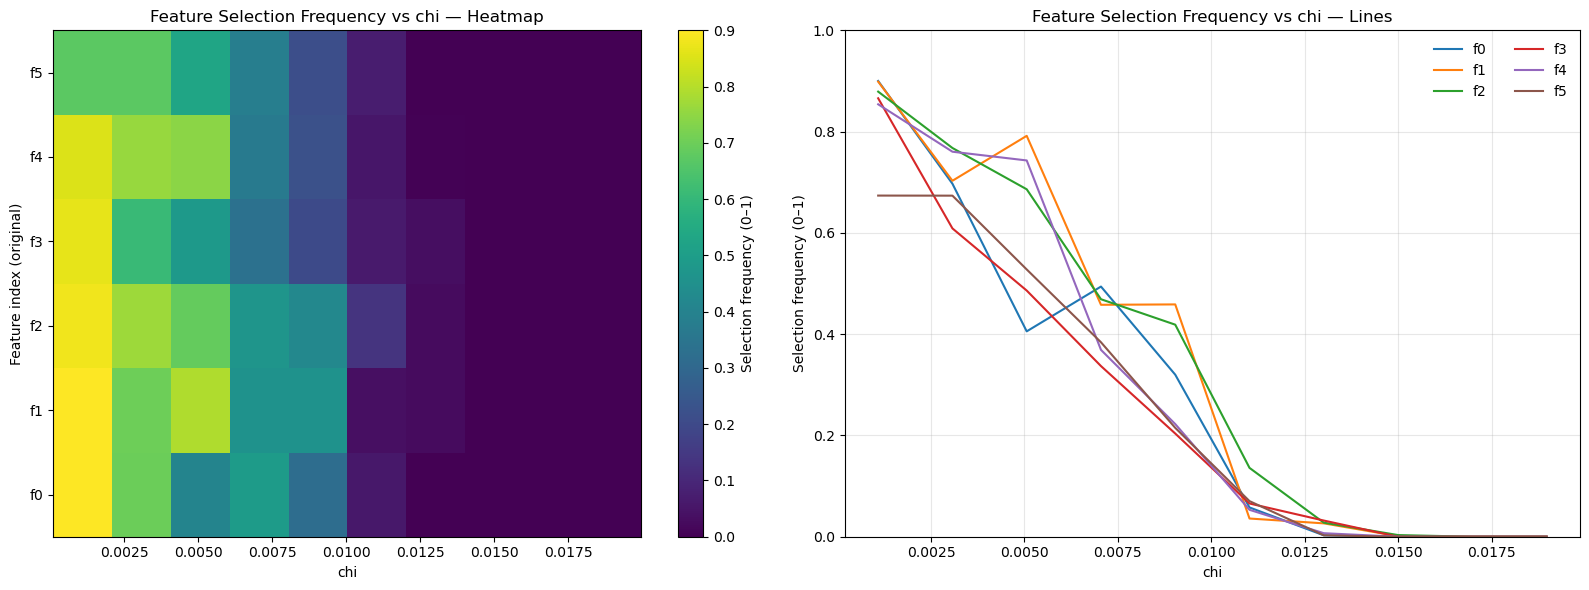

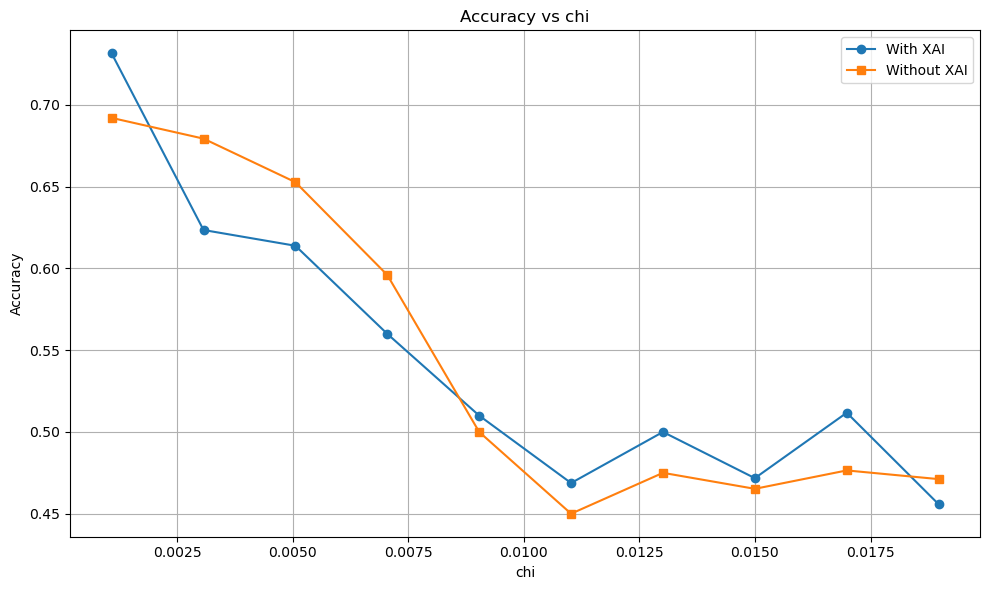

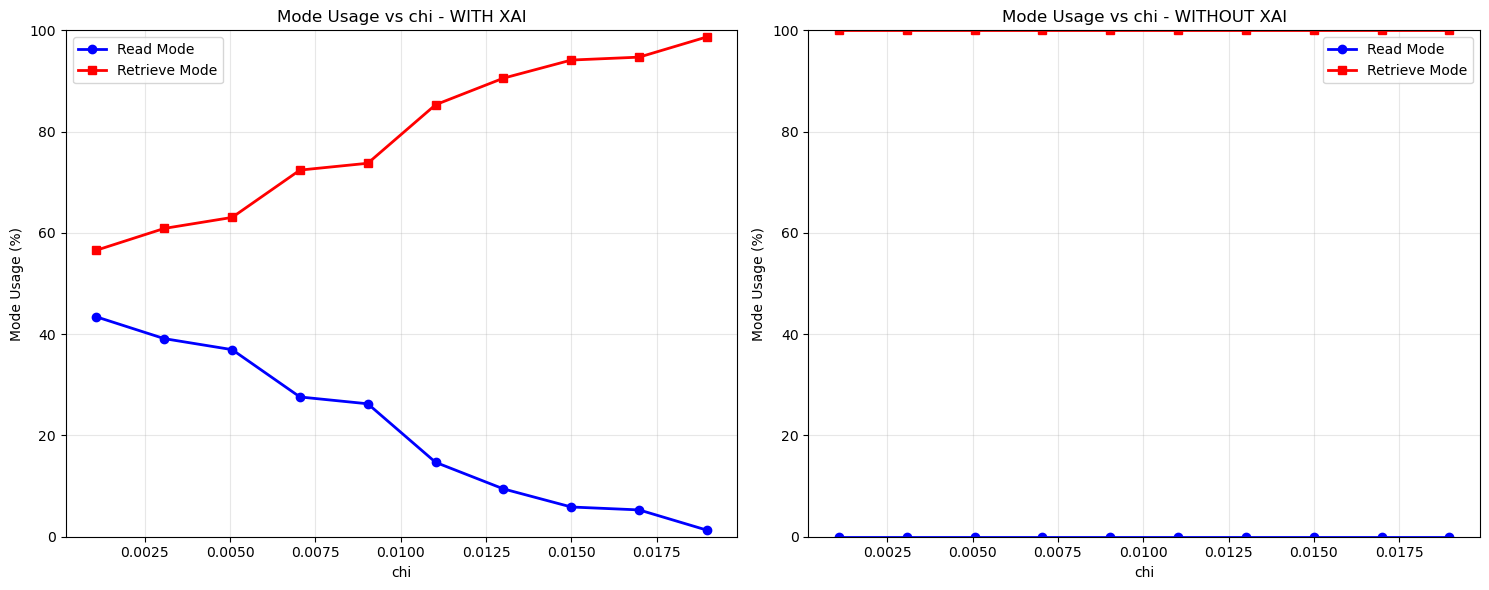


💾 Results saved to:
  - ./model_calculation/evaluation_results.csv
  - ./model_calculation/feature_selections.csv


In [13]:
def evaluate_trained_model(
    model_path: str = "./model_calculation/simple_chi_model.zip",
    n_episodes: int = 40,
    render_results: bool = True
):
    # Load model
    model = PPO.load(model_path)

    # === What you want to lock/change at EVAL ===
    eval_overrides = {
        # Example overrides; keep empty to use training-time sampling
        # "retrieval_threshold": -1.0,
        # "latency_factor": 0.0,
        # "T_enc": 1.0,
        # "T_op": 2.0,
        # "ddm_a": 1.0,
        # "ddm_s": 0.8,
        # "lapse": 0.05,
        "T_enc": 1.5,
        "T_op": 1.5,
        "ddm_s": 0.6,
        "retrieval_threshold": -1.0,
    }

    # --- helper to robustly decode actions (handles scalar/batched) ---
    def _to_1d_action(a):
        a = np.asarray(a)
        if a.ndim == 0:
            return np.array([int(a)], dtype=int)
        if a.ndim > 1:
            a = a[0]
        return a.astype(int).ravel()

    # Build eval env (must mirror training obs/action layout)
    def make_eval_env():
        env = LRForwardEval(
            instances_per_episode=40,
            max_features=6,
            xai_trial_ratio=0.5,
            ai_dataset_loaders={2: ai_data_loader2},
            lr_exps={2: lr_exp2},
            complexity="low",
            training_cog_params=training_cog_params,  # preserves obs space
            eval_overrides=eval_overrides,            # fixes any subset you want
            sample_remaining=True,                    # sample unspecified params
        )
        return env

    eval_env = make_eval_env()

    # Storage
    results = {
        "chi": [], "ddm_a": [], "ddm_a_bin": [],
        "chosen_mode": [], "with_xai": [],
        "prob_correct": [], "pred_time": [], "reward": [],
        "feature_masks_shuf": [], "feature_masks_orig": [], "correct": []
    }

    # Track all varied cog params from training for plotting later
    varied_keys = [k for k, v in training_cog_params.items()
                   if isinstance(v, (list, tuple)) and len(v) == 2]
    for k in varied_keys:
        results[f"cog_{k}"] = []

    print(f"🔍 Evaluating model for {n_episodes} episodes...")

    for episode in range(n_episodes):
        obs, info = eval_env.reset()
        done = False

        while not done:
            action, _states = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = eval_env.step(action)
            done = terminated or truncated

            # --- decode action: [strategy_id, ddm_a_bin, mask_0..mask_{F-1}] ---
            a1d = _to_1d_action(action)
            F = int(eval_env.max_features)
            expected_len = 2 + F  # strategy + ddm_a_bin + mask bits

            if a1d.size < expected_len:
                a_fixed = np.zeros(expected_len, dtype=int)
                a_fixed[:a1d.size] = a1d
            else:
                a_fixed = a1d[:expected_len]

            strategy_id = int(a_fixed[0])
            ddm_a_bin = int(a_fixed[1])
            feature_mask = a_fixed[2:2 + F].astype(int)

            # Map shuffled → original feature order
            perm = getattr(eval_env, "perm", None)
            if perm is None:
                perm = np.arange(F, dtype=int)

            feature_mask_orig = np.zeros(F, dtype=int)
            feature_mask_orig[perm] = feature_mask

            # --- log cogs (may be fixed by overrides) ---
            cog = info.get("cog_params", {})
            for k in varied_keys:
                results[f"cog_{k}"].append(cog.get(k, np.nan))

            # --- log step metrics ---
            results["ddm_a_bin"].append(ddm_a_bin)
            results["chi"].append(info.get("chi", 0.0))
            results["ddm_a"].append(info.get("ddm_a", 0.0))
            results["chosen_mode"].append(info.get("chosen_mode", "unknown"))
            results["with_xai"].append(info.get("with_xai_trial", False))
            results["prob_correct"].append(info.get("prob_correct", 0.0))
            results["pred_time"].append(info.get("pred_time", 0.0))
            results["reward"].append(reward)
            results["feature_masks_shuf"].append(feature_mask)
            results["feature_masks_orig"].append(feature_mask_orig)
            results["correct"].append(
                float(random.choices([0, 1], weights=[1 - info.get("prob_correct", 0.0),
                                                    info.get("prob_correct", 0.0)])[0])
            )

        if (episode + 1) % 5 == 0:
            print(f"📊 Completed {episode + 1}/{n_episodes} episodes")

    eval_env.close()

    # --- tidy arrays ---
    for key in list(results.keys()):
        if key not in ("feature_masks_shuf", "feature_masks_orig"):
            if isinstance(results[key], list):
                results[key] = np.asarray(results[key])

    if len(results["feature_masks_shuf"]) > 0:
        results["feature_masks_shuf"] = np.stack(results["feature_masks_shuf"]).astype(int)
        results["feature_masks_orig"] = np.stack(results["feature_masks_orig"]).astype(int)
    else:
        results["feature_masks_shuf"] = np.empty((0, eval_env.max_features), dtype=int)
        results["feature_masks_orig"] = np.empty((0, eval_env.max_features), dtype=int)

    # --- summary ---
    print("\n" + "="*50)
    print("📈 EVALUATION SUMMARY")
    print("="*50)
    print(f"Mean Accuracy: {np.mean(results['correct']):.3f}")
    print(f"Mean Reward: {np.mean(results['reward']):.3f}")
    print(f"Mean Chi Value: {np.mean(results['chi']):.4f}")
    print(f"Mean Features Selected: {np.mean(np.sum(results['feature_masks_orig'], axis=1)):.1f}")

    mode_counts = pd.Series(results["chosen_mode"]).value_counts()
    for mode, count in mode_counts.items():
        pct = 100 * count / len(results["chosen_mode"])
        print(f"{mode.capitalize()} Mode Usage: {pct:.1f}%")
    print("="*50)

    if render_results:
        plot_feature_selection_heatmap(results, eval_env, which="orig", by="chi")
        plot_accuracy_vs(results, by="chi")

    return results, eval_env


def _values_and_bins(results, env, by="chi", n_bins=10):
    """
    Returns (xvals, bins) for binning.
    'by' can be 'chi' or any varied cog param name (e.g., 'ddm_a', 'T_enc', ...).
    """
    if by == "chi":
        xvals = results["chi"]
    else:
        key = f"cog_{by}"
        if key not in results:
            raise ValueError(f"'{by}' is not tracked. Available: 'chi' or "
                             f"{[k.removeprefix('cog_') for k in results.keys() if k.startswith('cog_')]}")
        xvals = results[key]

    # guard for degenerate single-value arrays
    xmin, xmax = float(np.nanmin(xvals)), float(np.nanmax(xvals))
    if not np.isfinite(xmin) or not np.isfinite(xmax) or xmin == xmax:
        # make a tiny span to avoid zero-width bins
        xmin, xmax = xmin - 1e-6, xmax + 1e-6

    bins = np.linspace(xmin, xmax, n_bins + 1)
    return xvals, bins

def plot_accuracy_vs(results, by="chi", n_bins=10):
    """Plot accuracy vs any x-axis: 'chi' or a varied cog param (e.g., 'ddm_a')."""
    xvals, bins = _values_and_bins(results, env=None, by=by, n_bins=n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    correct = results["correct"]
    with_xai = results["with_xai"]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    for flag_val, label, marker in [(True, "With XAI", "o"), (False, "Without XAI", "s")]:
        acc = []
        for i in range(n_bins):
            mask = (with_xai == flag_val) & (xvals >= bins[i]) & (xvals < bins[i+1])
            acc.append(np.nanmean(correct[mask]) if np.any(mask) else np.nan)
        ax.plot(bin_centers, acc, marker=marker, linestyle="-", label=label)

    ax.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax.set_ylabel("Accuracy")
    ax.set_title(f"Accuracy vs {by}")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

def plot_feature_selection_heatmap(results, env, by="chi", n_bins=10, which="orig", show_legend=None):
    """
    Plots feature-selection frequency vs `by` as:
      • Left: heatmap (your original)
      • Right: line chart (one line per feature across bins)

    Args:
        results: evaluation dict
        env: the environment (for max_features)
        by: "chi" or a varied cog param name (e.g., "ddm_a")
        n_bins: number of bins for x-axis
        which: "orig" (recommended) or "shuf"
        show_legend: if None -> show legend only when max_features <= 10;
                     if True/False -> force legend on/off.
    """
    # --- binning & inputs ---
    xvals, bins = _values_and_bins(results, env, by, n_bins)
    if which == "orig":
        feature_masks = results["feature_masks_orig"]
        y_label = "Feature index (original)"
    elif which == "shuf":
        feature_masks = results["feature_masks_shuf"]
        y_label = "Feature index (shuffled)"
    else:
        raise ValueError("which must be 'orig' or 'shuf'")

    max_features = env.max_features
    bin_ids = np.digitize(xvals, bins) - 1
    bin_centers = 0.5 * (bins[:-1] + bins[1:])

    # --- aggregate selection frequencies per bin ---
    avg_masks = np.zeros((n_bins, max_features), dtype=float)  # [bin, feat]
    counts = np.zeros(n_bins, dtype=float)

    for i, b in enumerate(bin_ids):
        if 0 <= b < n_bins:
            mask = feature_masks[i]
            if len(mask) != max_features:
                tmp = np.zeros(max_features, dtype=float)
                n = min(len(mask), max_features)
                tmp[:n] = mask[:n]
                mask = tmp
            mask = np.asarray(mask, dtype=float)
            avg_masks[b] += mask
            counts[b] += 1.0

    with np.errstate(invalid="ignore", divide="ignore"):
        avg_masks = np.divide(
            avg_masks, counts[:, None],
            out=np.zeros_like(avg_masks),
            where=counts[:, None] > 0
        )
    # avg_masks shape: (n_bins, max_features), values in [0, 1]

    # --- plotting: heatmap (left) + line chart (right) ---
    fig, (ax_hm, ax_ln) = plt.subplots(1, 2, figsize=(16, 6))

    # Heatmap
    im = ax_hm.imshow(
        avg_masks.T, aspect="auto", origin="lower",
        extent=[bins[0], bins[-1], 0, max_features],
        cmap="viridis"
    )
    cbar = plt.colorbar(im, ax=ax_hm, label="Selection frequency (0–1)")
    ax_hm.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax_hm.set_ylabel(y_label)
    ax_hm.set_title(f"Feature Selection Frequency vs {by} — Heatmap")
    ax_hm.set_yticks(np.arange(max_features) + 0.5)
    ax_hm.set_yticklabels([f"f{i}" for i in range(max_features)])

    # Line chart: one line per feature across bins
    for feat in range(max_features):
        ax_ln.plot(
            bin_centers,
            avg_masks[:, feat],
            label=f"f{feat}",
        )
    ax_ln.set_xlabel(by if by == "chi" else f"{by} (cog param)")
    ax_ln.set_ylabel("Selection frequency (0–1)")
    ax_ln.set_title(f"Feature Selection Frequency vs {by} — Lines")
    ax_ln.set_ylim(0, 1)
    ax_ln.grid(True, alpha=0.3)

    # Legend policy (avoid clutter with many features)
    if show_legend is None:
        show_legend = (max_features <= 10)
    if show_legend:
        ax_ln.legend(ncol=2, frameon=False)

    plt.tight_layout()
    plt.show()

def plot_mode_usage_by_xai(results, env, by="chi", n_bins=10):
    """
    Plot mode usage (read vs retrieve) vs an x-axis ('chi' or any varied cog param),
    separated by with/without XAI trials.

    Args:
        results: dict from evaluation (must contain 'chosen_mode', 'with_xai',
                 'chi' or cog_<param> for non-chi plots)
        by: 'chi' or name of a varied cog param (e.g., 'ddm_a', 'T_enc', 'compute_sf')
        n_bins: number of bins on the x-axis
    """
    # Reuse generic binning (expects results["chi"] or results[f"cog_{by}"])
    xvals, bins = _values_and_bins(results, env=env, by=by, n_bins=n_bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    modes = np.asarray(results["chosen_mode"])
    with_xai = np.asarray(results["with_xai"], dtype=bool)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    colors  = {"read": "blue", "retrieve": "red"}
    markers = {"read": "o", "retrieve": "s"}
    panels = [
        (ax1, True,  "WITH XAI"),
        (ax2, False, "WITHOUT XAI"),
    ]

    # Helper to compute % usage per bin for a given mode and XAI flag
    def mode_pct_per_bin(target_mode, xai_flag):
        out = []
        for i in range(n_bins):
            # include right edge on last bin to capture max(xvals)
            in_bin = (xvals >= bins[i]) & ((xvals < bins[i+1]) if i < n_bins - 1 else (xvals <= bins[i+1]))
            mask = (with_xai == xai_flag) & in_bin
            if np.any(mask):
                bin_modes = modes[mask]
                out.append(100.0 * np.sum(bin_modes == target_mode) / len(bin_modes))
            else:
                out.append(np.nan)
        return out

    for ax, flag, title_suffix in panels:
        for mode_name in ["read", "retrieve"]:
            y = mode_pct_per_bin(mode_name, flag)
            ax.plot(
                bin_centers, y,
                marker=markers[mode_name], linestyle="-",
                color=colors[mode_name],
                label=f"{mode_name.capitalize()} Mode",
                linewidth=2, markersize=6,
            )
        x_label = by if by == "chi" else f"{by} (cog param)"
        ax.set_xlabel(x_label)
        ax.set_ylabel("Mode Usage (%)")
        ax.set_title(f"Mode Usage vs {by} - {title_suffix}")
        ax.legend()
        ax.grid(True, alpha=0.3)
        ax.set_ylim(0, 100)

    plt.tight_layout()
    plt.show()

# Run the evaluation
if __name__ == "__main__":
    results, eval_env = evaluate_trained_model(
        model_path="./model_calculation/best_model.zip",
        n_episodes=200,
        render_results=True
    )
    
    # Additional plots
    # plot_mode_usage_vs_chi(results)
    plot_mode_usage_by_xai(results, env=eval_env, by="chi")
    # Save results
    results_df = pd.DataFrame({
        k: (v.tolist() if isinstance(v, np.ndarray) and v.ndim > 1 else v)
        for k, v in results.items()
        if k not in ("feature_masks_shuf", "feature_masks_orig")
    })

    
    # Save feature masks separately
    feature_df = pd.DataFrame(
        results["feature_masks_orig"], 
        columns=[f"feature_{i}" for i in range(results["feature_masks_orig"].shape[1])]
    )
    
    results_df.to_csv("./model_calculation/evaluation_results.csv", index=False)
    feature_df.to_csv("./model_calculation/feature_selections.csv", index=False)
    
    print("\n💾 Results saved to:")
    print("  - ./model_calculation/evaluation_results.csv")
    print("  - ./model_calculation/feature_selections.csv")

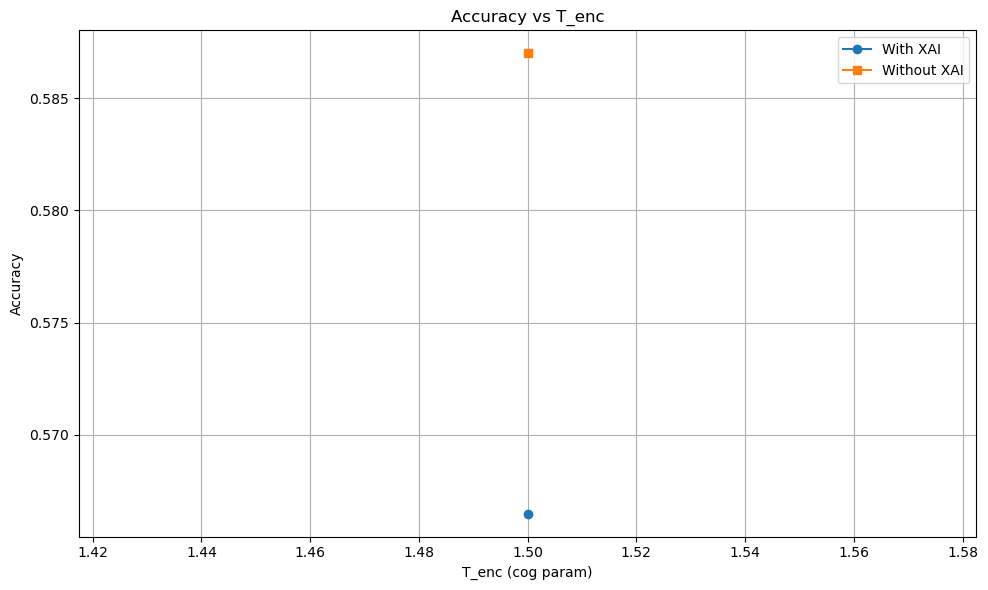

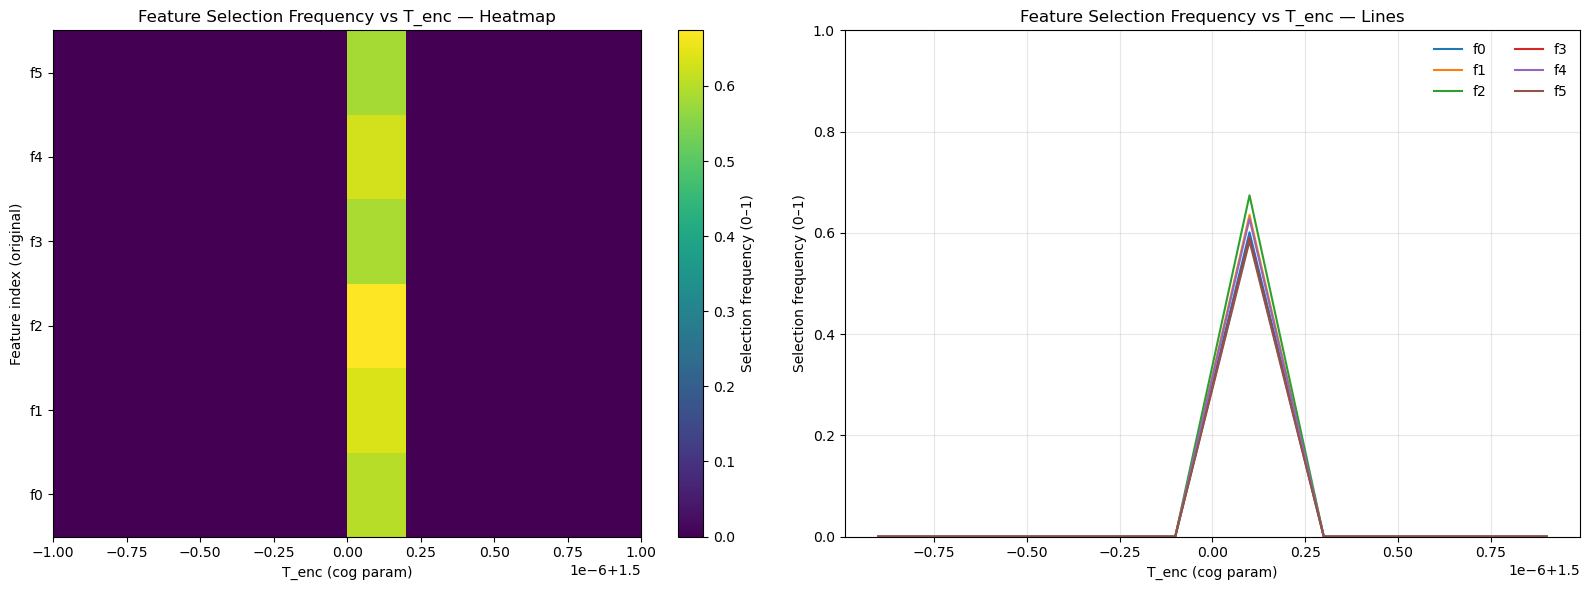

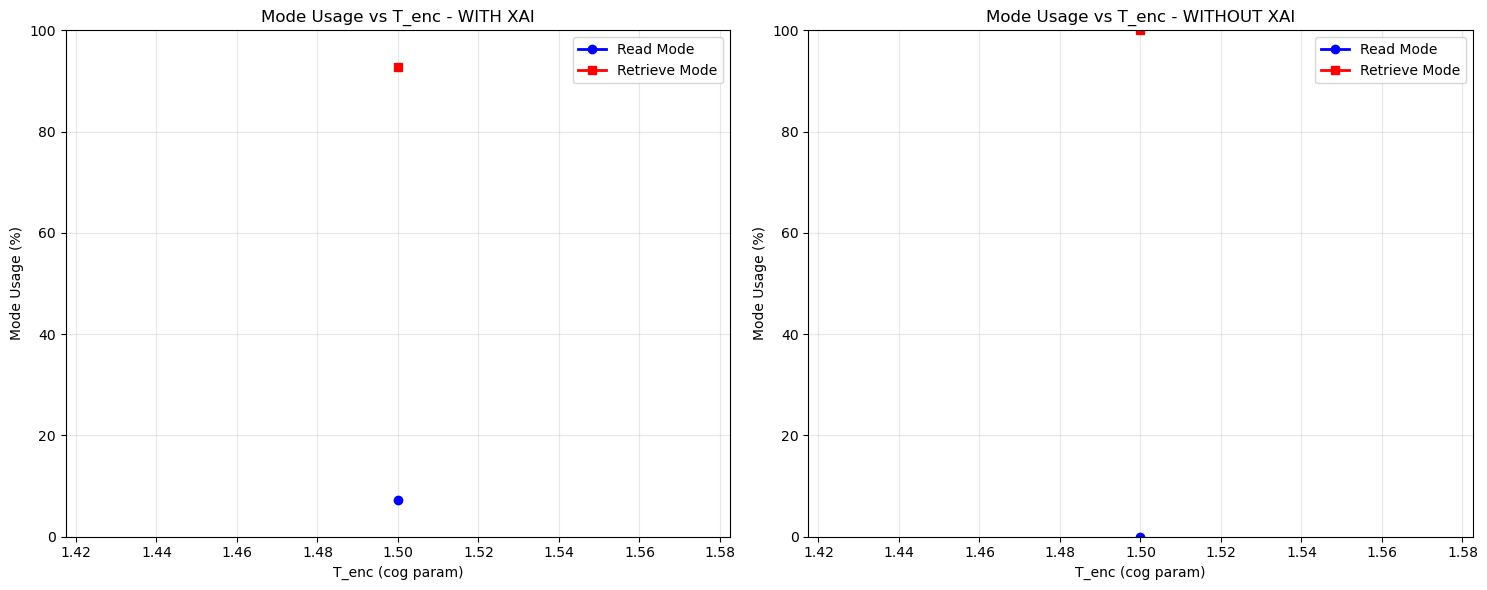

In [13]:
varied_param = "T_enc"  # example varied cog param
plot_accuracy_vs(results, by=varied_param, n_bins=10)
plot_feature_selection_heatmap(results, env=eval_env, by=varied_param, which="orig")
plot_mode_usage_by_xai(results, env=eval_env, by=varied_param)


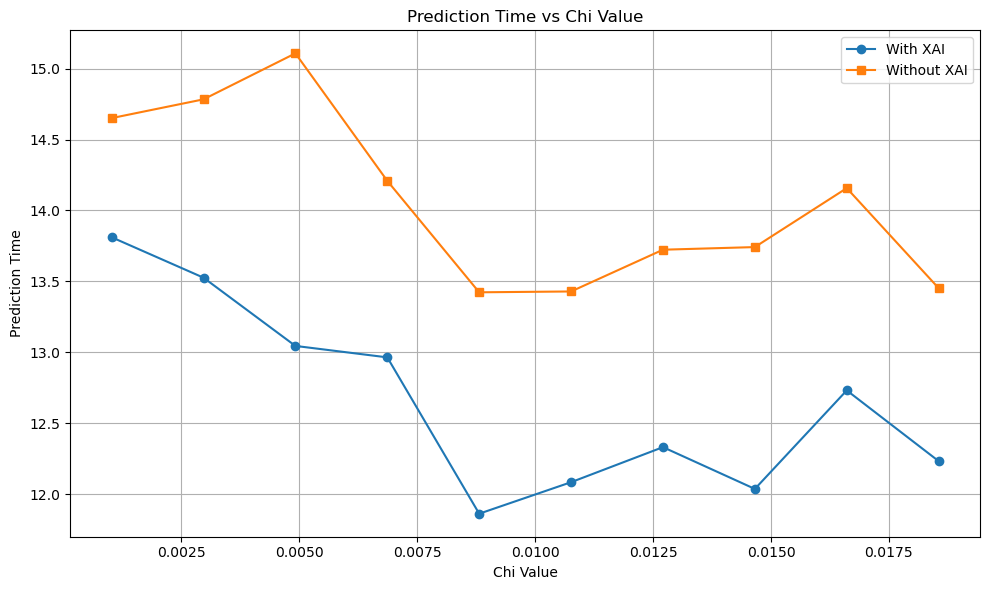

In [14]:
def plot_pred_time_vs_chi(results, n_bins=10):
    """
    Plot mean prediction time vs chi values, split by with/without XAI trials.
    """
    xvals = results["chi"]
    bins = np.linspace(xvals.min(), xvals.max(), n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    pred_time = results["pred_time"]
    with_xai = results["with_xai"]

    fig, ax = plt.subplots(1, 1, figsize=(10, 6))

    # Plot by with_xai flag
    for flag_val, label, marker in [(True, "With XAI", "o"), (False, "Without XAI", "s")]:
        mean_times = []
        for i in range(n_bins):
            mask = (with_xai == flag_val) & (xvals >= bins[i]) & (xvals < bins[i + 1])
            mean_times.append(np.nanmean(pred_time[mask]) if np.any(mask) else np.nan)

        ax.plot(bin_centers, mean_times, marker=marker, linestyle="-", label=label)

    ax.set_xlabel("Chi Value")
    ax.set_ylabel("Prediction Time")
    ax.set_title("Prediction Time vs Chi Value")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.show()

plot_pred_time_vs_chi(results)


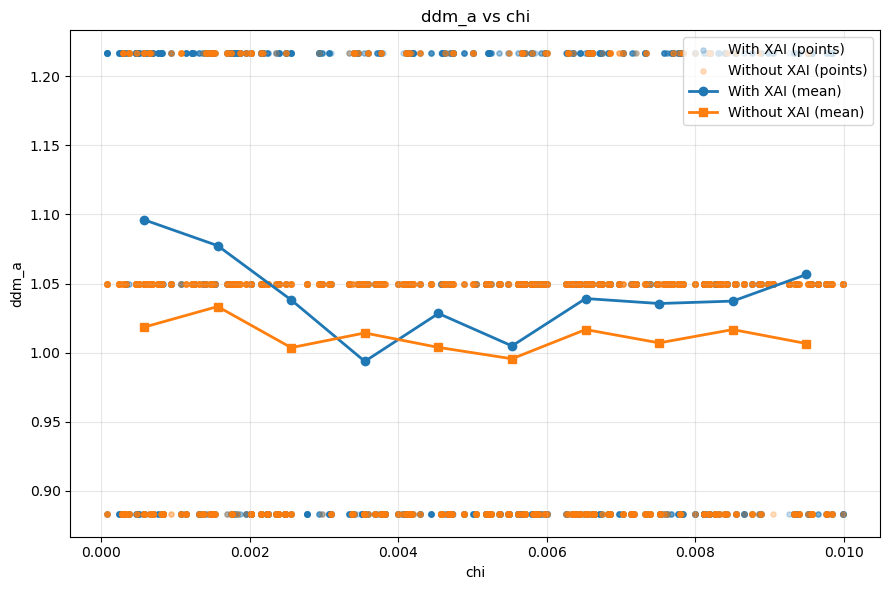

In [94]:

def plot_ddma_vs_chi(results, n_bins=10, show_scatter=True, split_by_xai=True):
    """
    Plot ddm_a vs chi. Uses results['ddm_a'] if available; otherwise results['cog_ddm_a'].
    Adds bin-averaged trend lines; optionally split by with/without XAI.

    Args:
        results: dict produced by evaluate_trained_model(...)
                 must contain 'chi' and either 'ddm_a' or 'cog_ddm_a'.
        n_bins: number of bins for trend lines.
        show_scatter: plot individual points (faded) in addition to trend lines.
        split_by_xai: draw separate lines for with/without XAI.
    """
    chi = np.asarray(results.get("chi", []), dtype=float)

    if "ddm_a" in results:
        ddma = np.asarray(results["ddm_a"], dtype=float)
    elif "cog_ddm_a" in results:
        ddma = np.asarray(results["cog_ddm_a"], dtype=float)
    else:
        raise ValueError("No ddm_a found. Provide results['ddm_a'] or results['cog_ddm_a'].")

    if chi.size == 0 or ddma.size == 0:
        raise ValueError("Empty inputs: chi or ddm_a has length 0.")

    # Align lengths if needed
    n = min(len(chi), len(ddma))
    chi, ddma = chi[:n], ddma[:n]

    # Mask invalids
    m = np.isfinite(chi) & np.isfinite(ddma)
    chi, ddma = chi[m], ddma[m]

    if chi.size == 0:
        raise ValueError("All chi/ddm_a values are NaN or inf after filtering.")

    # Bins for trend line(s)
    chi_min, chi_max = float(np.min(chi)), float(np.max(chi))
    if chi_min == chi_max:
        chi_min, chi_max = chi_min - 1e-6, chi_max + 1e-6
    bins = np.linspace(chi_min, chi_max, n_bins + 1)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    with_xai = np.asarray(results.get("with_xai", results.get("with_xai_trial", [])), dtype=bool)
    with_xai = with_xai[:len(chi)] if with_xai.size >= len(chi) else np.zeros_like(chi, dtype=bool)

    fig, ax = plt.subplots(1, 1, figsize=(9, 6))

    # Optional scatter
    if show_scatter:
        if split_by_xai:
            ax.scatter(chi[with_xai], ddma[with_xai], alpha=0.25, s=14, label="With XAI (points)")
            ax.scatter(chi[~with_xai], ddma[~with_xai], alpha=0.25, s=14, label="Without XAI (points)")
        else:
            ax.scatter(chi, ddma, alpha=0.25, s=14, label="Samples")

    # Trend lines (bin averages)
    def binned_means(mask):
        means = []
        for i in range(n_bins):
            in_bin = (chi >= bins[i]) & ((chi < bins[i+1]) if i < n_bins - 1 else (chi <= bins[i+1]))
            sel = in_bin & mask
            means.append(np.nanmean(ddma[sel]) if np.any(sel) else np.nan)
        return np.array(means, dtype=float)

    if split_by_xai:
        y_with  = binned_means(with_xai)
        y_without = binned_means(~with_xai)
        ax.plot(bin_centers, y_with,  linewidth=2, marker="o", label="With XAI (mean)")
        ax.plot(bin_centers, y_without, linewidth=2, marker="s", label="Without XAI (mean)")
    else:
        y_all = binned_means(np.ones_like(chi, dtype=bool))
        ax.plot(bin_centers, y_all, linewidth=2, marker="o", label="Mean")

    ax.set_xlabel("chi")
    ax.set_ylabel("ddm_a")
    ax.set_title("ddm_a vs chi")
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()
plot_ddma_vs_chi(results, n_bins=10, show_scatter=True, split_by_xai=True)


## Appendix: Code for fuller version

In [ ]:
# ===================== Action → Strategy mapping (outside the class) =====================

# 1–5 map onto: 2× LR-calculation (with/without XAI), 2× DT (with/without XAI), and 1× LR-heuristic (XAI follows trial flag)
STRATEGY_MAP = {
    1: {"strategy": "lr_calc", "with_xai": True},    # LR calculation, with XAI
    2: {"strategy": "lr_calc", "with_xai": False},   # LR calculation, without XAI
    3: {"strategy": "dt",       "with_xai": True},   # Decision Tree, with XAI
    4: {"strategy": "dt",       "with_xai": False},  # Decision Tree, without XAI
    5: {"strategy": "lr_heur",  "with_xai": None},   # LR heuristic; XAI will follow the trial's with_xai flag
}

def run_selected_strategy(
    action_id: int,
    *,
    instance_raw,         # numpy array (unnormalized instance)
    instance_norm,        # numpy array (normalized instance)
    memory,               # your CombinedMemory
    lr_exp=None,          # LogisticRegressionInterpreter (when needed)
    dt_exp=None,          # DecisionTreeInterpreter (when needed)
    with_xai_trial=False, # bool from the trial schedule
    active_indices=None,  # feature mask indices (list[int])
    # Strategy params (collected in the env from current_cog_params)
    T_enc=2.0, T_op=0.2, ddm_a=1.0, ddm_s=1.0, ddm_Tnd=0.30, ddm_norm="l2",
    compute_sf=2, lapse=0.0,
    num_samples=40, K_top=3,
):
    """
    Runs the chosen action via your existing _predict_once(strategy=..., ...) function.

    Returns: (probs, pred_time, aux_info)
    """
    spec = STRATEGY_MAP.get(int(action_id))
    if spec is None:
        raise ValueError(f"Unknown action id: {action_id}")

    strategy = spec["strategy"]
    with_xai = spec["with_xai"]
    # For lr_heuristic (action 5), let XAI follow the trial's schedule
    if with_xai is None:
        with_xai = bool(with_xai_trial)

    # Choose the right explainer for the strategy
    explainer = lr_exp if strategy in ("lr_calc", "lr_heur") else dt_exp

    # Delegate to your existing function (must be defined/imported elsewhere)
    probs, pred_time, aux = _predict_once(
        strategy,
        instance_raw,            # instance (unnormalized) for lr_calc/dt; your function also accepts norm_instance separately
        instance_norm,
        memory, explainer,
        with_xai=with_xai,
        T_enc=T_enc, T_op=T_op,
        ddm_a=ddm_a, ddm_s=ddm_s,
        compute_sf=compute_sf
    )
    return probs, float(pred_time), aux


# ============================== The RL Environment class ==============================

import gym
from gym import spaces
import numpy as np

class LRForward(gym.Env):
    """
    Minimal environment that chooses among 5 strategy actions + a feature mask.

    Actions:
      1: LR calculation  (with XAI)
      2: LR calculation  (without XAI)
      3: Decision Tree   (with XAI)
      4: Decision Tree   (without XAI)
      5: LR heuristic    (XAI follows the trial's with_xai flag)

    Observation (float32):
      [chi_norm, trial_idx_norm, with_xai_flag,
       strategy_counts[5], strategy_success_rates[5],
       per-feature contribution-std distribution [max_features],
       (optional) varied cognitive params...]

    Reward:
      prob_correct - chi * pred_time
    """

    metadata = {"render_modes": ["human"]}

    def __init__(self,
                 instances_per_episode: int = 40,
                 max_features: int = 6,
                 chi_low: float = 0.0,
                 chi_high: float = 0.03,
                 xai_trial_ratio: float = 0.5,
                 ai_dataset_loaders=None,     # dict[key] -> loader
                 lr_exps=None,                # dict[key] -> LR explainer
                 dt_exps=None,                # dict[key] -> DT explainer
                 training: bool = True,
                 cog_params: dict = None,     # dict of defaults or ranges (lo,hi)
                 condition: str = "Hybrid",   # "LR", "DT", or "Hybrid"
                 complexity: str = "low",     # "low" or "high"
                ):
        super().__init__()

        self.instances_per_episode = int(instances_per_episode)
        self.max_features = int(max_features)
        self.chi_low = float(chi_low)
        self.chi_high = float(chi_high)
        self.xai_trial_ratio = float(xai_trial_ratio)

        self.ai_dataset_loaders = ai_dataset_loaders or {}
        self.lr_exps = lr_exps or {}
        self.dt_exps = dt_exps or {}

        # Action = strategy id (1..5) + feature mask (binary per feature)
        self.action_space = spaces.MultiDiscrete([6] + [2] * self.max_features)  # 0..5, we will treat 0 as invalid (penalty)

        self.cog_params = cog_params or {}
        self.num_varied_cogparam = 0
        self.varied_cogparams_low = []
        self.varied_cogparams_high = []
        for k, v in self.cog_params.items():
            if isinstance(v, (list, tuple)) and len(v) == 2:
                self.num_varied_cogparam += 1
                self.varied_cogparams_low.append(float(v[0]))
                self.varied_cogparams_high.append(float(v[1]))

        # Observation space bounds
        low_vec = [0.0, 0.0, 0.0]                                  # chi_norm, trial_norm, with_xai_flag
        high_vec = [1.0, 1.0, 1.0]

        low_vec += [0.0] * 5                                       # strategy_counts (lo)
        high_vec += [float(self.instances_per_episode)] * 5        # strategy_counts (hi)

        low_vec += [0.0] * 5                                       # strategy_success rates (lo)
        high_vec += [1.0] * 5                                      # success rates (hi)

        low_vec += [0.0] * self.max_features                       # per-feature std-dist (lo)
        high_vec += [1.0] * self.max_features                      # per-feature std-dist (hi)

        if self.num_varied_cogparam > 0:
            low_vec += self.varied_cogparams_low
            high_vec += self.varied_cogparams_high

        self.observation_space = spaces.Box(
            low=np.array(low_vec, dtype=np.float32),
            high=np.array(high_vec, dtype=np.float32),
            dtype=np.float32,
        )

        self.step_idx = 0
        self.curr_chi = 0.0
        self.training = bool(training)

        # Track per-strategy usage and success (5 strategies now)
        self.strategy_counts = np.zeros(5, dtype=np.int32)
        self.strategy_success = np.zeros(5, dtype=np.float32)

        self.condition = condition
        self.complexity = complexity

        self.memory = None
        self.lr_exp = None
        self.dt_exp = None
        self.ai_dataset_loader = None

        self.contributions = {i: [] for i in range(self.max_features)}
        self.trials = None
        self.current_cog_params = {}

    # ---------------------- internal helpers ----------------------

    def _initialize_memory(self):
        memory_param_default = dict(
            retrieval_threshold=0.5,
            latency_factor=3.0,
            latency_exponent=0.5,
            max_assoc_strength=2.0,
            mismatch_penalty=-1.0,
            activation_noise=0.1,
            decay=0.5,
        )

        # override from current episode's cognitive params if provided
        for k, v in (self.current_cog_params or {}).items():
            if isinstance(v, (int, float)) and k in memory_param_default:
                memory_param_default[k] = float(v)

        dm = DeclarativeMemory(**memory_param_default)
        self.memory = CombinedMemory(dm, wm_capacity=10)

        # Optionally seed LR/DT knowledge
        if self.lr_exp is not None:
            add_lr_calculation_to_memory(self.lr_exp, self.memory)
            add_lr_heuristic_to_memory(self.lr_exp, self.memory, initial_sigma=0.1)
        if self.dt_exp is not None:
            add_dt_to_memory(self.memory, dt_exp=self.dt_exp, thresh_sf=2)

        self.memory.tick(90)

    def generate_episode_conditions(self):
        """
        Returns a list of per-trial dicts: {with_xai, model_type, complexity}.
        If self.condition is "LR" or "DT", all trials use that model_type.
        If "Hybrid", trials are half LR and half DT (shuffled).
        """
        rng = np.random.default_rng()
        n = self.instances_per_episode
        n_xai = round(n * self.xai_trial_ratio)

        flags = np.array([1] * n_xai + [0] * (n - n_xai))
        rng.shuffle(flags)

        if self.condition in ("LR", "DT"):
            trials = [dict(with_xai=bool(f), model_type=self.condition, complexity=self.complexity) for f in flags]
        else:
            n_lr = n // 2
            trials = (
                [dict(with_xai=bool(f), model_type="LR", complexity=self.complexity) for f in flags[:n_lr]] +
                [dict(with_xai=bool(f), model_type="DT", complexity=self.complexity) for f in flags[n_lr:]]
            )
            rng.shuffle(trials)
        return trials

    def _get_strategy_params(self):
        """
        Collect strategy-level knobs (timing & diffusion & display precision),
        allowing episode-varying overrides from self.current_cog_params.
        """
        params = dict(
            T_enc=2.0,
            T_op=0.2,
            ddm_a=1.0,
            ddm_s=1.0,
            ddm_Tnd=0.30,
            ddm_norm="l2",
            compute_sf=2,
            lapse=0.05,
            num_samples=40,
            K_top=3,
        )
        for k, v in (self.current_cog_params or {}).items():
            if k in params and isinstance(v, (int, float)):
                params[k] = float(v)
        return params

    def _build_obs(self):
        # guard
        if self.step_idx >= self.instances_per_episode:
            # return a valid zero-like obs if called after episode end
            zeros = np.zeros(self.observation_space.shape, dtype=np.float32)
            return zeros

        # With-XAI flag for current trial
        with_xai_flag = float(bool(self.trials[self.step_idx]["with_xai"]))

        # Feature contribution tracking (per-step update)
        x_raw = self.X_raw[self.step_idx]
        # Update contribution history per feature
        for feat in range(min(self.max_features, x_raw.shape[-1])):
            factor_value = self.lr_exp.coefficients.get(f"a{feat}", 0.0) if (self.lr_exp is not None and hasattr(self.lr_exp, "coefficients")) else 0.0
            self.contributions[feat].append(float(x_raw[feat]) * float(factor_value))

        # Compute per-feature std; normalize to sum=1 (if any non-zero)
        feature_stds = np.array([
            np.std(self.contributions[i]) if len(self.contributions[i]) > 1 else 0.0
            for i in range(self.max_features)
        ], dtype=np.float32)
        if feature_stds.sum() > 0:
            partial_sums_std = (feature_stds / feature_stds.sum()).astype(np.float32)
        else:
            partial_sums_std = feature_stds

        base = [
            float(self.curr_chi / max(self.chi_high, 1e-9)),
            float(self.step_idx / max(self.instances_per_episode, 1)),
            with_xai_flag,
            *self.strategy_counts.tolist(),
            *self.strategy_success.tolist(),
            *partial_sums_std.tolist(),
        ]

        if self.num_varied_cogparam > 0:
            cog_params_obs = [
                float(self.current_cog_params.get(k, 0.0))
                for k, v in self.cog_params.items()
                if isinstance(v, (list, tuple)) and len(v) == 2
            ]
            base += cog_params_obs

        return np.asarray(base, dtype=np.float32)

    # --------------------------- Gym API ---------------------------

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        rng = np.random.default_rng(seed)

        self.trials = self.generate_episode_conditions()

        # Randomly select a dataset key and bind loaders/experts
        if not self.ai_dataset_loaders:
            raise RuntimeError("ai_dataset_loaders is empty; provide at least one dataset loader.")
        dataset_key = rng.choice(list(self.ai_dataset_loaders.keys()))
        self.ai_dataset_loader = self.ai_dataset_loaders[dataset_key]
        self.lr_exp = (self.lr_exps or {}).get(dataset_key, None)
        self.dt_exp = (self.dt_exps or {}).get(dataset_key, None)

        # Sample/assign cognitive params for this episode
        self.current_cog_params = {}
        for k, v in (self.cog_params or {}).items():
            if isinstance(v, (list, tuple)) and len(v) == 2:
                self.current_cog_params[k] = float(rng.uniform(v[0], v[1]))
            elif isinstance(v, (int, float)):
                self.current_cog_params[k] = float(v)

        self.step_idx = 0
        self.curr_chi = float(rng.uniform(self.chi_low, self.chi_high))
        self._initialize_memory()

        # Reset trackers
        self.strategy_counts[:] = 0
        self.strategy_success[:] = 0.0
        self.contributions = {i: [] for i in range(self.max_features)}

        # Sample instances for the episode (adapt to your dataset size)
        all_idx = list(range(1, 400))
        idx = rng.choice(all_idx, size=self.instances_per_episode, replace=False).tolist()
        inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
        inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)
        self.X_raw = np.asarray(inst_raw, dtype=np.float32)
        self.X_norm = np.asarray(inst_norm, dtype=np.float32)
        self.y = np.asarray(labels, dtype=np.int64)

        return self._build_obs(), {}

    def step(self, action):
        action = np.asarray(action, dtype=np.int64)
        action_id = int(action[0])
        mask_bits = action[1:].tolist()
        active_indices = [i for i, b in enumerate(mask_bits[:self.max_features]) if b == 1]

        # Hard-guard invalid action id 0 or >5
        if action_id not in STRATEGY_MAP:
            info = {"error": f"Invalid action id {action_id}", "chi": self.curr_chi}
            self.step_idx += 1
            truncated = self.step_idx >= self.instances_per_episode
            return self._build_obs(), -5.0, False, truncated, info

        # Current trial info
        trial = self.trials[self.step_idx]
        with_xai_trial = bool(trial["with_xai"])

        # Instances
        x_raw = self.X_raw[self.step_idx]
        x_norm = self.X_norm[self.step_idx]
        y_true = int(self.y[self.step_idx])

        # Get shared strategy params from episode-varying cognitive settings
        SP = self._get_strategy_params()

        # Run the chosen strategy (delegated outside the class)
        probs, pred_time, _ = run_selected_strategy(
            action_id,
            instance_raw=x_raw,
            instance_norm=x_norm,
            memory=self.memory,
            lr_exp=self.lr_exp,
            dt_exp=self.dt_exp,
            with_xai_trial=with_xai_trial,
            active_indices=active_indices,
            T_enc=SP["T_enc"], T_op=SP["T_op"],
            ddm_a=SP["ddm_a"], ddm_s=SP["ddm_s"],
            ddm_Tnd=SP["ddm_Tnd"], ddm_norm=SP["ddm_norm"],
            compute_sf=SP["compute_sf"], lapse=SP["lapse"],
            num_samples=int(SP["num_samples"]), K_top=int(SP["K_top"]),
        )

        # Reward: prob(correct) − chi × time   (optionally lapse-mix for reward too)
        prob_correct = float(probs[y_true])
        if SP["lapse"] > 0.0:
            prob_correct = (1.0 - SP["lapse"]) * prob_correct + 0.5 * SP["lapse"]
        reward = prob_correct - float(self.curr_chi) * float(pred_time)

        # Update per-strategy stats (index: 0..4 for actions 1..5)
        idx = action_id - 1
        self.strategy_counts[idx] += 1
        n = self.strategy_counts[idx]
        old_mean = self.strategy_success[idx]
        self.strategy_success[idx] = (old_mean * (n - 1) + (1.0 if prob_correct > 0.5 else 0.0)) / max(n, 1)

        # Advance time
        self.step_idx += 1
        truncated = self.step_idx >= self.instances_per_episode

        obs = self._build_obs()
        info = {
            "action_id": action_id,
            "with_xai_trial": with_xai_trial,
            "active_indices": active_indices,
            "prob_correct": prob_correct,
            "pred_time": float(pred_time),
            "chi": self.curr_chi,
            "cog_params": dict(self.current_cog_params),
        }
        return obs, float(reward), False, truncated, info


In [ ]:
import os
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
import torch.nn as nn

# Make sure these are imported/defined somewhere:
# - LRForward (the new env you just built)
# - ai_data_loader1, ai_data_loader2 (or however many you want)
# - lr_exp1, lr_exp2 (LR explainers)
# - dt_exp1, dt_exp2 (DT explainers)
# - _predict_once, STRATEGY_MAP, run_selected_strategy (if not in same module, import them)

def train_simple_chi_model(
    total_timesteps: int = 50_000,
    n_envs: int = 4,
    save_path: str = "./model_calculation/simple_chi_model.zip",
    log_path: str = None,
    ppo_kwargs: dict = None,
) -> PPO:
    """
    Minimal PPO training loop for the LRForward environment.
    Extra PPO kwargs can be passed via `ppo_kwargs`.
    """
    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    # --------- vectorized env factory ---------
    def make_env(rank: int):
        def _init():
            # Example: two datasets; map integers -> loaders/experts
            env = LRForward(
                instances_per_episode=40,
                max_features=6,
                chi_low=0.0,
                chi_high=0.01,                 # matches your earlier SimpleChi setting
                xai_trial_ratio=0.5,
                ai_dataset_loaders={1: ai_data_loader1, 2: ai_data_loader2},
                lr_exps={1: lr_exp1, 2: lr_exp2},
                dt_exps={1: dt_exp1, 2: dt_exp2},
                training=True,
                # Episode-varying cognitive parameters (ranges or fixed values)
                cog_params={
                    # Memory-level (DeclarativeMemory) knobs
                    "retrieval_threshold": [0.0, 2.0],
                    "latency_factor": [1.0, 5.0],
                    "latency_exponent": 0.5,
                    "max_assoc_strength": 2.0,
                    "mismatch_penalty": -1.0,
                    "activation_noise": 0.1,
                    "decay": 0.5,
                    "wm_capacity": 10,  # if your CombinedMemory reads this; else ignored

                    # Strategy-level knobs (used by _predict_once via env._get_strategy_params)
                    "T_enc": [1.0, 3.0],
                    "T_op": [0.05, 0.5],
                    "ddm_a": [0.5, 2.0],
                    "ddm_s": [0.3, 1.5],
                    "ddm_Tnd": 0.30,
                    "ddm_norm": "l2",
                    "compute_sf": [1.0, 3.0],
                    "lapse": [0.01, 0.2],
                    "num_samples": 40,
                    "K_top": 3,
                },
                condition="Hybrid",            # "LR", "DT", or "Hybrid"
                complexity="low",
            )
            return Monitor(env)
        return _init

    # --------- build vec envs (DummyVecEnv for simplicity) ---------
    train_env = DummyVecEnv([make_env(i) for i in range(n_envs)])
    eval_env = DummyVecEnv([make_env(999)])
    eval_env.training = False

    # --------- PPO defaults (override via ppo_kwargs) ---------
    default_kwargs = dict(
        policy="MlpPolicy",
        env=train_env,
        verbose=1,
        tensorboard_log=log_path,
        policy_kwargs=dict(
            net_arch=[dict(pi=[64, 64], vf=[64, 64])],
            activation_fn=nn.Tanh,
        ),
    )
    if ppo_kwargs:
        default_kwargs.update(ppo_kwargs)

    model = PPO(**default_kwargs)

    # --------- Eval callback ---------
    # Ensure eval_freq is an integer >= 1
    eval_freq = max(int(10000 / max(n_envs, 1)), 1)
    eval_callback = EvalCallback(
        eval_env,
        eval_freq=eval_freq,
        best_model_save_path=os.path.dirname(save_path),
    )

    print(f"🏃 Training for {int(total_timesteps):,} steps with {n_envs} env(s)...")
    model.learn(total_timesteps=int(total_timesteps), callback=eval_callback, progress_bar=True)

    print(f"💾 Saving model to {save_path}")
    model.save(save_path)

    train_env.close()
    eval_env.close()
    return model


if __name__ == "__main__":
    # Example: run training with some PPO customizations
    model = train_simple_chi_model(
        total_timesteps=int(5e5),
        n_envs=4,
        ppo_kwargs=dict(
            learning_rate=1e-3,
            ent_coef=0.01,
            gamma=0.8,
            verbose=0,
            device="cpu",  # set to 'cuda' if you have a GPU
        ),
    )


In [ ]:
# # ====== Gymnasium Env: LR-Calc Feature-Selection for Stable-Baselines ======
# # Requirements (import in your notebook/script):
# # pip install gymnasium numpy
# # (Stable-Baselines3 can interact with this env; it only requires standard Gymnasium API.)

# import math
# import numpy as np
# from collections import deque
# from typing import Dict, List, Optional, Tuple

# import gymnasium as gym
# from gymnasium import spaces

# # --- You must already have these imported from your codebase ---
# # from your_module import (
# #     DeclarativeMemory, CombinedMemory,
# #     lr_calculation, add_lr_calculation_to_memory, refresh_lr_calculation_in_memory,
# #     filter_by_app_and_model    # if you organize loaders like in cell 4 (optional)
# # )

# class LRCalcFeatureSelectEnv(gym.Env):
#     """
#     RL environment for **feature selection** using the LR calculation strategy only.

#     Action space:
#         - MultiBinary(max_features): a binary mask selecting which features are "active".

#     Observation space (vector):
#         [
#           0) chi_value (scalar, normalized: chi / chi_high)
#           1..8) cognitive parameters (8 scalars, in this order and normalized by their bounds):
#                 [T_enc, T_op, retrieval_threshold, latency_factor, ddm_a, ddm_s, lapse, compute_sf]
#           9) with_xai flag (0 or 1)
#           10) accumulated_accuracy (running mean correctness in [0,1])
#           11..15) past_correctness_history (5 entries, each 0 or 1; 0 when not filled yet)
#           16) last_reward (from the previous step; 0.0 at reset)
#           17) current_prediction (probability of the true class at this step)
#           18) prediction_time (seconds, model-produced)
#         ]

#     Episode flow:
#         - On each step, the agent selects a feature mask.
#         - The env runs `lr_calculation` with those active features:
#               mode="read" if with_xai else "retrieve"
#         - Reward = prob_correct - chi * pred_time   (consistent with cell 5 design)
#         - If with_xai=True, memory is refreshed via `refresh_lr_calculation_in_memory`.

#     Notes:
#         - The environment samples/schedules with-XAI trials according to `xai_trial_ratio`.
#         - Cognitive params are sampled uniformly within provided bounds unless fixed values are given.
#         - Dataset indices are sampled without replacement each episode.
#         - This env assumes:
#             * `ai_dataset_loader` exposes: load_instances(ids, normalize=False/True)
#               and optionally filter_by_app_and_model() if you pass app/model IDs.
#             * `explainer` is the LR explainer object used by lr_calculation.
#             * Memory helpers (DeclarativeMemory, CombinedMemory, add_lr_calculation_to_memory, refresh_lr_calculation_in_memory)
#               are available in the namespace (see your cell 4).
#     """

#     metadata = {"render_modes": ["human"]}

#     # ---- Bounds for cognitive parameters (from your spec) ----
#     BOUNDS = {
#         "T_enc": (0.05, 10.0),
#         "T_op": (0.05, 1.0),
#         "retrieval_threshold": (-2.0, -0.1),
#         "latency_factor": (0.3, 3.0),
#         "ddm_a": (0.5, 3.0),
#         "ddm_s": (0.5, 2.0),
#         "lapse": (0.0, 0.3),
#         "compute_sf": (1.0, 3.0),
#     }

#     COG_PARAM_ORDER = [
#         "T_enc", "T_op", "retrieval_threshold", "latency_factor",
#         "ddm_a", "ddm_s", "lapse", "compute_sf"
#     ]

#     def __init__(
#         self,
#         *,
#         instances_per_episode: int = 64,
#         max_features: int = 6,
#         chi_low: float = 0.0,
#         chi_high: float = 0.3,
#         xai_trial_ratio: float = 0.5,
#         ai_dataset_loader=None,   # required: must implement load_instances()
#         explainer=None,           # required: LR explainer used by lr_calculation
#         model_name: Optional[str] = None,   # optional, for loader filtering
#         app_id: Optional[str] = None,       # optional, for loader filtering
#         # Fix some cognitive params (dict) or leave None to sample within bounds.
#         fixed_cog_params: Optional[Dict[str, float]] = None,
#         # Reward scalars
#         time_penalty_scale: float = 0.1,    # final chi used is chi_value * time_penalty_scale
#         # Dataset indexing
#         instance_id_pool: Optional[List[int]] = None,  # default: 1..400
#         seed: Optional[int] = None
#     ):
#         super().__init__()

#         assert ai_dataset_loader is not None, "ai_dataset_loader is required."
#         assert explainer is not None, "explainer (LR explainer) is required."

#         self.rng = np.random.default_rng(seed)
#         self.instances_per_episode = int(instances_per_episode)
#         self.max_features = int(max_features)
#         self.chi_low = float(chi_low)
#         self.chi_high = float(chi_high)
#         self.xai_trial_ratio = float(xai_trial_ratio)
#         self.ai_dataset_loader = ai_dataset_loader
#         self.explainer = explainer
#         self.model_name = model_name
#         self.app_id = app_id
#         self.fixed_cog_params = fixed_cog_params or {}
#         self.time_penalty_scale = float(time_penalty_scale)
#         self.instance_id_pool = instance_id_pool if instance_id_pool is not None else list(range(1, 400))

#         # --- Action space: choose which features are active ---
#         self.action_space = spaces.MultiBinary(self.max_features)

#         # --- Observation space ---
#         # Low/High vectors must be concrete. We normalize bounded items to [0,1] where possible.
#         # chi (normalized), 8 cog params (normalized 0..1), with_xai, acc, 5 history, last_reward, prob, pred_time
#         obs_len = 1 + 8 + 1 + 1 + 5 + 1 + 1 + 1
#         low = np.zeros(obs_len, dtype=np.float32)
#         high = np.ones(obs_len, dtype=np.float32)
#         # last_reward can be negative; allow some range
#         low[16] = -1.0  # last_reward
#         high[16] = 1.0
#         # pred_time can be larger than 1; set a generous cap (e.g., 30s)
#         low[18] = 0.0
#         high[18] = 30.0
#         self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

#         # --- Episode state ---
#         self.step_idx: int = 0
#         self.curr_chi: float = 0.0
#         self.with_xai_schedule: np.ndarray = np.zeros(self.instances_per_episode, dtype=np.int32)
#         self.memory = None

#         # Data buffers
#         self.X_raw = None
#         self.X_norm = None
#         self.y = None

#         # Stats
#         self.accumulated_accuracy = 0.0
#         self.correct_history = deque(maxlen=5)
#         self.last_reward = 0.0
#         self.last_prob_correct = 0.0
#         self.last_pred_time = 0.0

#         # Current cognitive params (dict)
#         self.cog_params: Dict[str, float] = {}

#     # ---------- Helpers ----------
#     @staticmethod
#     def _normalize(value: float, lo: float, hi: float) -> float:
#         return float((value - lo) / (hi - lo + 1e-12))

#     def _normalize_cogs(self, params: Dict[str, float]) -> List[float]:
#         vals = []
#         for k in self.COG_PARAM_ORDER:
#             lo, hi = self.BOUNDS[k]
#             vals.append(self._normalize(params[k], lo, hi))
#         return vals

#     def _initialize_memory(self):
#         """
#         Build a DeclarativeMemory + CombinedMemory consistent with cell 4,
#         using *current* cognitive parameters for memory-related fields.
#         """
#         # memory params derived from cognitive params
#         dm = DeclarativeMemory(
#             retrieval_threshold=self.cog_params["retrieval_threshold"],
#             latency_factor=self.cog_params["latency_factor"],
#             latency_exponent=0.5,
#             max_assoc_strength=2.0,
#             mismatch_penalty=-1.0,
#             activation_noise=0.3,
#             decay=0.5,
#         )
#         self.memory = CombinedMemory(dm, wm_capacity=7)
#         # Preload LR coefficients/state for calculation path
#         add_lr_calculation_to_memory(self.explainer, self.memory)
#         self.memory.tick(10)

#     def _build_obs(self, with_xai_flag: int) -> np.ndarray:
#         # chi normalized
#         chi_norm = self.curr_chi / max(self.chi_high, 1e-9)

#         # normalized cogs
#         cog_norm = self._normalize_cogs(self.cog_params)

#         # pad history to length 5 for early steps
#         hist = list(self.correct_history)
#         if len(hist) < 5:
#             hist = hist + [0.0] * (5 - len(hist))
#         hist = hist[:5]

#         obs = np.array(
#             [chi_norm] +
#             cog_norm +
#             [float(with_xai_flag)] +
#             [float(self.accumulated_accuracy)] +
#             [float(h) for h in hist] +
#             [float(self.last_reward)] +
#             [float(self.last_prob_correct)] +
#             [float(self.last_pred_time)],
#             dtype=np.float32
#         )
#         return obs

#     def _sample_cog_params(self) -> Dict[str, float]:
#         params = {}
#         for k in self.COG_PARAM_ORDER:
#             if k in self.fixed_cog_params and isinstance(self.fixed_cog_params[k], (int, float)):
#                 params[k] = float(self.fixed_cog_params[k])
#             else:
#                 lo, hi = self.BOUNDS[k]
#                 params[k] = float(self.rng.uniform(lo, hi))
#         # compute_sf is discrete display SF in {1,2,3}; sample continuous then snap
#         cs_lo, cs_hi = self.BOUNDS["compute_sf"]
#         params["compute_sf"] = int(np.clip(round(params["compute_sf"]), cs_lo, cs_hi))
#         return params

#     # ---------- Gymnasium API ----------
#     def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
#         if seed is not None:
#             self.rng = np.random.default_rng(seed)

#         # Schedule with-XAI flags
#         n = self.instances_per_episode
#         n_xai = int(round(n * self.xai_trial_ratio))
#         flags = np.array([1] * n_xai + [0] * (n - n_xai), dtype=np.int32)
#         self.rng.shuffle(flags)
#         self.with_xai_schedule = flags

#         # Cognitive params
#         self.cog_params = self._sample_cog_params()

#         # Initialize memory
#         self._initialize_memory()

#         # Draw chi and instances
#         self.curr_chi = float(self.rng.uniform(self.chi_low, self.chi_high))

#         idx = self.rng.choice(self.instance_id_pool, size=self.instances_per_episode, replace=False).tolist()
#         inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
#         inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)

#         self.X_raw = np.asarray(inst_raw, dtype=np.float32)
#         self.X_norm = np.asarray(inst_norm, dtype=np.float32)
#         self.y = np.asarray(labels, dtype=np.int64)

#         # Reset stats
#         self.step_idx = 0
#         self.accumulated_accuracy = 0.0
#         self.correct_history.clear()
#         self.last_reward = 0.0
#         self.last_prob_correct = 0.0
#         self.last_pred_time = 0.0

#         obs = self._build_obs(with_xai_flag=int(self.with_xai_schedule[0]))
#         info = {"cog_params": self.cog_params.copy(), "chi": self.curr_chi}
#         return obs, info

#     def step(self, action):
#         # Validate and parse action -> active feature indices
#         action = np.asarray(action, dtype=np.int64).flatten()
#         if action.size != self.max_features:
#             raise ValueError(f"Expected action of size {self.max_features}, got {action.size}")
#         active_indices = [i for i, b in enumerate(action.tolist()) if b == 1]

#         # End if already past episode length
#         terminated = False
#         truncated = self.step_idx >= self.instances_per_episode
#         if truncated:
#             return self._build_obs(with_xai_flag=0), 0.0, terminated, truncated, {}

#         # Fetch trial info
#         with_xai = bool(self.with_xai_schedule[self.step_idx])

#         # Current instance
#         x_raw = self.X_raw[self.step_idx]
#         y_true = int(self.y[self.step_idx])

#         # Map required cog params
#         T_enc = float(self.cog_params["T_enc"])
#         T_op = float(self.cog_params["T_op"])
#         ddm_a = float(self.cog_params["ddm_a"])
#         ddm_s = float(self.cog_params["ddm_s"])
#         compute_sf = int(self.cog_params["compute_sf"])
#         lapse = float(self.cog_params["lapse"])  # optional post-mix

#         # Run LR calculation with the selected features
#         # In your lr_calculation signature, pass 'active_indices' if supported; else, handle masking inside.
#         probs, pred_time, aux = lr_calculation(
#             x_raw, self.memory, lr_exp=self.explainer,
#             T_enc=T_enc, T_op=T_op, ddm_a=ddm_a, ddm_s=ddm_s,
#             compute_sf=compute_sf,
#             mode=("read" if with_xai else "retrieve"),
#             # active_indices=active_indices,   # uncomment if your lr_calculation supports it
#         )

#         # Select probability of the TRUE label (assuming probs=[p0,p1])
#         p_true = float(probs[y_true])
#         if lapse > 0.0:
#             p_true = (1.0 - lapse) * p_true + 0.5 * lapse

#         # Reward: accuracy term minus time cost scaled by chi (like cell 5)
#         reward = p_true - (self.curr_chi * self.time_penalty_scale) * float(pred_time)

#         # If read-with-XAI, refresh memory (as specified)
#         if with_xai:
#             refresh_lr_calculation_in_memory(
#                 self.memory, self.explainer,
#                 intercept_display_sf=int(compute_sf),
#                 factor_display_sf=int(compute_sf),
#             )

#         # Update stats
#         correct = 1.0 if p_true > 0.5 else 0.0
#         self.correct_history.append(correct)
#         self.accumulated_accuracy = (
#             (self.accumulated_accuracy * self.step_idx + correct) / (self.step_idx + 1)
#         )

#         # Advance
#         self.step_idx += 1
#         truncated = self.step_idx >= self.instances_per_episode

#         # Save lasts
#         self.last_reward = float(reward)
#         self.last_prob_correct = float(p_true)
#         self.last_pred_time = float(pred_time)

#         # Build next obs (with next with_xai flag if available)
#         next_with_xai_flag = int(self.with_xai_schedule[self.step_idx - 1] if truncated else self.with_xai_schedule[self.step_idx])
#         obs = self._build_obs(with_xai_flag=next_with_xai_flag)

#         info = {
#             "active_indices": active_indices,
#             "with_xai": with_xai,
#             "prob_correct": float(p_true),
#             "pred_time": float(pred_time),
#             "y_true": y_true,
#             "cog_params": self.cog_params.copy(),
#             "chi": self.curr_chi,
#         }
#         return obs, float(reward), terminated, truncated, info

#     # Optional: Stable-Baselines may call render/close
#     def render(self):
#         pass

#     def close(self):
#         pass


In [ ]:
# # ====== Gymnasium Env: LR-Calc Feature-Selection
# # —— dataset- & complexity-specific retrievers for (loader, explainer) pairs ——
# # Notes:
# # • Action = MultiBinary(max_features) (feature mask)
# # • Observation includes the *past* feature mask (length=max_features)
# # • At reset(), the env picks a dataset_id (random or via options["dataset_id"])
# #   and a complexity ∈ {"low","high"}; it then retrieves the matching (loader, explainer).
# # • Only the LR calculation strategy is used; memory refresh happens only when with_xai=True.

# import numpy as np
# from collections import deque
# from typing import Dict, List, Optional, Any

# import gymnasium as gym
# from gymnasium import spaces

# # --- You must provide these from your codebase ---
# # from your_module import (
# #     DeclarativeMemory, CombinedMemory,
# #     lr_calculation, add_lr_calculation_to_memory, refresh_lr_calculation_in_memory
# # )

# class LRCalcFeatureSelectEnv(gym.Env):
#     """
#     Constructor expects `datasets` shaped like:
#         datasets = {
#             "<dataset_id_A>": {
#                 "low":  {"loader": <LoaderA_low>,  "explainer": <ExplainerA_low>},
#                 "high": {"loader": <LoaderA_high>, "explainer": <ExplainerA_high>},
#             },
#             "<dataset_id_B>": {
#                 "low":  {"loader": <LoaderB_low>,  "explainer": <ExplainerB_low>},
#                 "high": {"loader": <LoaderB_high>, "explainer": <ExplainerB_high>},
#             },
#             ...
#         }

#     Observation vector (order):
#       [ chi_norm,
#         8 * normalized cognitive params
#           (T_enc, T_op, retrieval_threshold, latency_factor, ddm_a, ddm_s, lapse, compute_sf),
#         with_xai_flag,
#         accumulated_accuracy,
#         5 * past_correctness_history,
#         last_reward,
#         last_prob_correct,
#         last_pred_time,
#         max_features * past_feature_mask
#       ]

#     Reward:
#         r = p_true - (chi * time_penalty_scale) * pred_time
#     """

#     metadata = {"render_modes": ["human"]}

#     # Bounds per spec
#     BOUNDS = {
#         "T_enc": (0.05, 10.0),
#         "T_op": (0.05, 1.0),
#         "retrieval_threshold": (-2.0, -0.1),
#         "latency_factor": (0.3, 3.0),
#         "ddm_a": (0.5, 3.0),
#         "ddm_s": (0.5, 2.0),
#         "lapse": (0.0, 0.3),
#         "compute_sf": (1.0, 3.0),
#     }
#     COG_PARAM_ORDER = [
#         "T_enc", "T_op", "retrieval_threshold", "latency_factor",
#         "ddm_a", "ddm_s", "lapse", "compute_sf"
#     ]

#     def __init__(
#         self,
#         *,
#         datasets: Dict[str, Dict[str, Dict[str, Any]]],  # {dataset_id: {"low":{"loader","explainer"},"high":{...}}}
#         instances_per_episode: int = 64,
#         max_features: int = 6,
#         chi_low: float = 0.0,
#         chi_high: float = 0.03,
#         xai_trial_ratio: float = 0.5,
#         complexity_high_ratio: float = 0.5,   # P(episode complexity = "high")
#         fixed_cog_params: Optional[Dict[str, float]] = None,
#         time_penalty_scale: float = 1.0,
#         instance_id_pool: Optional[List[int]] = None,
#         seed: Optional[int] = None,
#     ):
#         super().__init__()
#         if not datasets:
#             raise ValueError("`datasets` mapping is required and cannot be empty.")
#         self.datasets = datasets
#         self.dataset_ids = list(datasets.keys())

#         self.rng = np.random.default_rng(seed)
#         self.instances_per_episode = int(instances_per_episode)
#         self.max_features = int(max_features)
#         self.chi_low, self.chi_high = float(chi_low), float(chi_high)
#         self.xai_trial_ratio = float(xai_trial_ratio)
#         self.complexity_high_ratio = float(np.clip(complexity_high_ratio, 0.0, 1.0))
#         self.fixed_cog_params = fixed_cog_params or {}
#         self.time_penalty_scale = float(time_penalty_scale)
#         self.instance_id_pool = instance_id_pool if instance_id_pool is not None else list(range(1, 400))

#         # Selected per episode
#         self.dataset_id: Optional[str] = None
#         self.episode_complexity: str = "low"    # "low" | "high"
#         self.ai_dataset_loader = None
#         self.explainer = None

#         # Action: choose active features
#         self.action_space = spaces.MultiBinary(self.max_features)

#         # Observation space (see class docstring)
#         len_base = 1                 # chi_norm
#         len_cogs = 8                 # normalized cogs
#         len_flags = 1                # with_xai flag
#         len_acc = 1                  # accumulated_accuracy
#         len_hist = 5                 # correctness history
#         len_tail = 3                 # last_reward, last_prob_correct, last_pred_time
#         len_mask = self.max_features # past feature-selection mask
#         obs_len = len_base + len_cogs + len_flags + len_acc + len_hist + len_tail + len_mask

#         low = np.zeros(obs_len, dtype=np.float32)
#         high = np.ones(obs_len, dtype=np.float32)
#         # last_reward (start of tail)
#         last_reward_idx = len_base + len_cogs + len_flags + len_acc + len_hist
#         low[last_reward_idx] = -1.0
#         high[last_reward_idx] = 1.0
#         # last_pred_time (tail index +2)
#         last_pred_time_idx = last_reward_idx + 2
#         low[last_pred_time_idx] = 0.0
#         high[last_pred_time_idx] = 30.0

#         self.observation_space = spaces.Box(low=low, high=high, dtype=np.float32)

#         # Episode state
#         self.step_idx = 0
#         self.curr_chi = 0.0
#         self.with_xai_schedule = np.zeros(self.instances_per_episode, dtype=np.int32)
#         self.memory = None

#         # Data buffers
#         self.X_raw = None
#         self.X_norm = None
#         self.y = None

#         # Stats
#         self.accumulated_accuracy = 0.0
#         self.correct_history = deque(maxlen=len_hist)
#         self.last_reward = 0.0
#         self.last_prob_correct = 0.0
#         self.last_pred_time = 0.0
#         self.last_feature_mask = np.zeros(self.max_features, dtype=np.float32)

#         # Current cognitive params
#         self.cog_params: Dict[str, float] = {}

#     # ---------------- Helpers ----------------
#     @staticmethod
#     def _normalize(v: float, lo: float, hi: float) -> float:
#         return float((v - lo) / (hi - lo + 1e-12))

#     def _normalize_cogs(self, params: Dict[str, float]) -> List[float]:
#         return [self._normalize(params[k], *self.BOUNDS[k]) for k in self.COG_PARAM_ORDER]

#     def _choose_complexity(self) -> str:
#         return "high" if self.rng.random() < self.complexity_high_ratio else "low"

#     def _pick_dataset_and_bind(self, *, dataset_id: Optional[str], complexity: str):
#         """
#         Choose a dataset_id (random if None) and bind loader/explainer
#         for the requested complexity ("low" or "high").
#         """
#         if dataset_id is None:
#             dataset_id = self.rng.choice(self.dataset_ids).item() if hasattr(self.rng.choice(self.dataset_ids), "item") else self.rng.choice(self.dataset_ids)
#         if dataset_id not in self.datasets:
#             raise KeyError(f"dataset_id '{dataset_id}' not found in provided datasets.")
#         if complexity not in self.datasets[dataset_id]:
#             raise KeyError(f"complexity '{complexity}' not available for dataset_id '{dataset_id}'.")

#         entry = self.datasets[dataset_id][complexity]
#         if not isinstance(entry, dict) or "loader" not in entry or "explainer" not in entry:
#             raise ValueError(f"datasets['{dataset_id}']['{complexity}'] must be a dict with 'loader' and 'explainer'.")

#         self.dataset_id = dataset_id
#         self.ai_dataset_loader = entry["loader"]
#         self.explainer = entry["explainer"]

#     def _initialize_memory(self):
#         dm = DeclarativeMemory(
#             retrieval_threshold=self.cog_params["retrieval_threshold"],
#             latency_factor=self.cog_params["latency_factor"],
#             latency_exponent=0.5,
#             max_assoc_strength=2.0,
#             mismatch_penalty=-1.0,
#             activation_noise=0.3,
#             decay=0.5,
#         )
#         self.memory = CombinedMemory(dm, wm_capacity=7)
#         add_lr_calculation_to_memory(self.explainer, self.memory)
#         self.memory.tick(10)

#     def _build_obs(self, with_xai_flag: int) -> np.ndarray:
#         chi_norm = self.curr_chi / max(self.chi_high, 1e-9)
#         cog_norm = self._normalize_cogs(self.cog_params)
#         hist = list(self.correct_history)
#         if len(hist) < self.correct_history.maxlen:
#             hist += [0.0] * (self.correct_history.maxlen - len(hist))

#         obs = np.array(
#             [chi_norm] +
#             cog_norm +
#             [float(with_xai_flag)] +
#             [float(self.accumulated_accuracy)] +
#             [float(h) for h in hist] +
#             [float(self.last_reward), float(self.last_prob_correct), float(self.last_pred_time)],
#             dtype=np.float32
#         )
#         obs = np.concatenate([obs, self.last_feature_mask.astype(np.float32)], dtype=np.float32)
#         return obs

#     def _sample_cog_params(self) -> Dict[str, float]:
#         params = {}
#         for k in self.COG_PARAM_ORDER:
#             if k in self.fixed_cog_params and isinstance(self.fixed_cog_params[k], (int, float)):
#                 params[k] = float(self.fixed_cog_params[k])
#             else:
#                 lo, hi = self.BOUNDS[k]
#                 params[k] = float(self.rng.uniform(lo, hi))
#         # Snap compute_sf to {1,2,3}
#         lo_cs, hi_cs = self.BOUNDS["compute_sf"]
#         params["compute_sf"] = int(np.clip(round(params["compute_sf"]), lo_cs, hi_cs))
#         return params

#     # ---------------- Gymnasium API ----------------
#     def reset(self, *, seed: Optional[int] = None, options: Optional[dict] = None):
#         if seed is not None:
#             self.rng = np.random.default_rng(seed)

#         # 1) Choose complexity and dataset_id (respect options if provided)
#         self.episode_complexity = self._choose_complexity()
#         ds_id_opt = None
#         if options and isinstance(options, dict) and "dataset_id" in options:
#             ds_id_opt = str(options["dataset_id"])
#         self._pick_dataset_and_bind(dataset_id=ds_id_opt, complexity=self.episode_complexity)

#         # 2) Build with-XAI schedule
#         n = self.instances_per_episode
#         n_xai = int(round(n * self.xai_trial_ratio))
#         flags = np.array([1] * n_xai + [0] * (n - n_xai), dtype=np.int32)
#         self.rng.shuffle(flags)
#         self.with_xai_schedule = flags

#         # 3) Cognitive params & memory
#         self.cog_params = self._sample_cog_params()
#         self._initialize_memory()

#         # 4) Episode chi
#         self.curr_chi = float(self.rng.uniform(self.chi_low, self.chi_high))

#         # 5) Data for this episode from the chosen loader
#         idx = self.rng.choice(self.instance_id_pool, size=self.instances_per_episode, replace=False).tolist()
#         inst_raw, labels = self.ai_dataset_loader.load_instances(idx, normalize=False)
#         inst_norm, _ = self.ai_dataset_loader.load_instances(idx, normalize=True)
#         self.X_raw = np.asarray(inst_raw, dtype=np.float32)
#         self.X_norm = np.asarray(inst_norm, dtype=np.float32)  # kept if you later need normalized
#         self.y = np.asarray(labels, dtype=np.int64)

#         # 6) Reset stats
#         self.step_idx = 0
#         self.accumulated_accuracy = 0.0
#         self.correct_history.clear()
#         self.last_reward = 0.0
#         self.last_prob_correct = 0.0
#         self.last_pred_time = 0.0
#         self.last_feature_mask = np.zeros(self.max_features, dtype=np.float32)

#         obs = self._build_obs(with_xai_flag=int(self.with_xai_schedule[0]))
#         info = {
#             "dataset_id": self.dataset_id,
#             "episode_complexity": self.episode_complexity,
#             "cog_params": self.cog_params.copy(),
#             "chi": self.curr_chi,
#         }
#         return obs, info

#     def step(self, action):
#         action = np.asarray(action, dtype=np.int64).flatten()
#         if action.size != self.max_features:
#             raise ValueError(f"Expected action of size {self.max_features}, got {action.size}")
#         active_indices = [i for i, b in enumerate(action.tolist()) if b == 1]

#         terminated = False
#         truncated = self.step_idx >= self.instances_per_episode
#         if truncated:
#             return self._build_obs(with_xai_flag=0), 0.0, terminated, truncated, {}

#         with_xai = bool(self.with_xai_schedule[self.step_idx])

#         x_raw = self.X_raw[self.step_idx]
#         y_true = int(self.y[self.step_idx])

#         T_enc = float(self.cog_params["T_enc"])
#         T_op = float(self.cog_params["T_op"])
#         ddm_a = float(self.cog_params["ddm_a"])
#         ddm_s = float(self.cog_params["ddm_s"])
#         compute_sf = int(self.cog_params["compute_sf"])
#         lapse = float(self.cog_params["lapse"])

#         # Run LR calculation (mask inside lr_calculation if supported)
#         probs, pred_time, _ = lr_calculation(
#             x_raw, self.memory, lr_exp=self.explainer,
#             T_enc=T_enc, T_op=T_op, ddm_a=ddm_a, ddm_s=ddm_s,
#             compute_sf=compute_sf,
#             mode=("read" if with_xai else "retrieve"),
#             # active_indices=active_indices,  # uncomment if your lr_calculation supports feature masking
#         )

#         p_true = float(probs[y_true])
#         if lapse > 0.0:
#             p_true = (1.0 - lapse) * p_true + 0.5 * lapse

#         reward = p_true - (self.curr_chi * self.time_penalty_scale) * float(pred_time)

#         if with_xai:
#             refresh_lr_calculation_in_memory(
#                 self.memory, self.explainer,
#                 intercept_display_sf=int(compute_sf),
#                 factor_display_sf=int(compute_sf),
#             )

#         correct = 1.0 if p_true > 0.5 else 0.0
#         self.correct_history.append(correct)
#         self.accumulated_accuracy = (
#             (self.accumulated_accuracy * self.step_idx + correct) / (self.step_idx + 1)
#         )

#         self.step_idx += 1
#         truncated = self.step_idx >= self.instances_per_episode

#         # Update past feature mask for NEXT observation
#         self.last_feature_mask = action.astype(np.float32)

#         self.last_reward = float(reward)
#         self.last_prob_correct = float(p_true)
#         self.last_pred_time = float(pred_time)

#         next_with_xai_flag = int(self.with_xai_schedule[self.step_idx - 1] if truncated
#                                  else self.with_xai_schedule[self.step_idx])
#         obs = self._build_obs(with_xai_flag=next_with_xai_flag)

#         info = {
#             "dataset_id": self.dataset_id,
#             "episode_complexity": self.episode_complexity,
#             "active_indices": active_indices,
#             "with_xai": with_xai,
#             "prob_correct": float(p_true),
#             "pred_time": float(pred_time),
#             "y_true": y_true,
#             "cog_params": self.cog_params.copy(),
#             "chi": self.curr_chi,
#         }
#         return obs, float(reward), terminated, truncated, info

#     def render(self): pass
#     def close(self): pass
